In [171]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly as pl

In [172]:
import pandas as pd
import numpy as np

results = pd.read_csv('../../training_results.csv')
# Extract the part of the experiment name that contains the run number
# The run number is the last part of the name after splitting by '_'
run_number_part = results['experiment'].str.split('_').str[-1]

# Calculate 'run number' by counting the number of '2's in that part
results['run_number'] = run_number_part.str.count('2')

# Define the cleaning methods. We put 'labels' first to signify its priority.
# The final category order will be based on this list.
cleaning_methods = [
    'labels',
    'flowmop_doublet',
    'flowmop_debris',
    'flowmop_time',
    'flowcut',
    'peacoqc',
    'flowmop',
    'base' 
]

# --- Corrected Cleaning Method Extraction ---

# Initialize the column with a placeholder
results['cleaning_method'] = pd.NA

# Step 1: Prioritize 'labels'. If the experiment name contains 'labels', assign it.
# This ensures 'labels' takes precedence over any other keywords.
label_mask = results['experiment'].str.contains('labels')
results.loc[label_mask, 'cleaning_method'] = 'labels'

# Step 2: For all other experiments, use the regex pattern.
# We create a pattern from all methods *except* 'labels'.
other_methods = [m for m in cleaning_methods if m != 'labels']
pattern = f'({"|".join(other_methods)})'

# Apply the pattern only to the rows that were not identified as 'labels'.
results.loc[~label_mask, 'cleaning_method'] = results.loc[~label_mask, 'experiment'].str.extract(pattern, expand=False)

# Handle any experiment names that still didn't match.
results['cleaning_method'].fillna('unknown', inplace=True)

# Convert the column to a 'Categorical' data type to enforce a consistent order for plotting.
final_categories = cleaning_methods
if 'unknown' in results['cleaning_method'].unique():
    final_categories = cleaning_methods + ['unknown']

results['cleaning_method'] = pd.Categorical(
    results['cleaning_method'], 
    categories=final_categories, 
    ordered=True
)

print("Cleaning methods extracted and categorized:")
print(results['cleaning_method'].value_counts())

# Extract 'training_proportion' using a regular expression
# This looks for a number (int or float) just before the run information (e.g., _2_222)
results['training_proportion'] = results['experiment'].str.extract(r'_(\d+\.?\d*)_2_?2*?$').astype(float)

# Determine 'nsubsample' based on the presence of '40000' in the experiment name
results['nsubsample'] = np.where(results['experiment'].str.contains('40000'), 40000, 20000)
results.drop("experiment", axis=1, inplace=True)
# Display the first few rows of the modified DataFrame to verify the changes

results = results.reindex(sorted(results.columns), axis=1)
results.head()

Cleaning methods extracted and categorized:
cleaning_method
flowmop_debris     75
flowmop_time       75
flowcut            75
peacoqc            75
flowmop            75
base               75
labels             60
flowmop_doublet    55
Name: count, dtype: int64


C:\Users\Tony\AppData\Local\Temp\ipykernel_18372\578034939.py:44: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  results['cleaning_method'].fillna('unknown', inplace=True)


,cleaning_method,epochs_trained,loss,nsubsample,run_number,testing_acc,testing_auc,training_proportion,val_acc,val_auc,val_loss
0,flowcut,50,0.074784,20000,5,0.500,0.561,0.10,0.968819,0.998211,0.080783
1,flowcut,50,0.274646,40000,8,0.710,0.834,0.75,0.914418,0.972916,0.224790
2,flowmop,50,0.245078,40000,7,0.710,0.780,0.50,0.919320,0.976226,0.204574
3,flowcut,50,0.313060,40000,2,0.790,0.880,0.75,0.895829,0.959216,0.271786
4,flowmop_time,50,0.293872,40000,9,0.806,0.858,0.50,0.906821,0.969070,0.236677


In [173]:
grouped_results = results.groupby(['cleaning_method', 'nsubsample', 'training_proportion'])
grouped_results.mean()

C:\Users\Tony\AppData\Local\Temp\ipykernel_18372\3947254519.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_results = results.groupby(['cleaning_method', 'nsubsample', 'training_proportion'])


epochs_trained      loss  \
cleaning_method nsubsample training_proportion                             
labels          20000      0.10                           13.0  0.148016   
                           0.25                           41.4  0.228411   
                           0.50                           42.0  0.340264   
                           0.75                           50.0  0.360857   
                           1.00                           49.4  0.385603   
...                                                        ...       ...   
base            40000      0.10                           37.1  0.066375   
                           0.25                           47.7  0.179158   
                           0.50                           47.9  0.299106   
                           0.75                           49.1  0.337361   
                           1.00                           49.8  0.356570   

                                                run_number  testing_acc  \
cleaning_method nsubsample training_proportion                            
labels          20000      0.10                        3.0       0.5616   
                           0.25                        3.0       0.7130   
                           0.50                        3.0       0.6968   
                           0.75                        3.0       0.7356   
                           1.00                        3.0       0.7322   
...                                                    ...          ...   
base            40000      0.10                        5.5       0.5887   
                           0.25                        5.5       0.7146   
                           0.50                        5.5       0.7694   
                           0.75                        5.5       0.7886   
                           1.00                        5.5       0.7757   

                                                testing_auc   val_acc  \
cleaning_method nsubsample training_proportion                          
labels          20000      0.10                      0.6056  0.858463   
                           0.25                      0.7636  0.846994   
                           0.50                      0.7724  0.815395   
                           0.75                      0.7958  0.811858   
                           1.00                      0.8146  0.807609   
...                                                     ...       ...   
base            40000      0.10                      0.6356  0.956032   
                           0.25                      0.7835  0.924281   
                           0.50                      0.8419  0.881921   
                           0.75                      0.8663  0.860772   
                           1.00                      0.8726  0.851958   

                                                 val_auc  val_loss  
cleaning_method nsubsample training_proportion                      
labels          20000      0.10                 0.930814  0.477312  
                           0.25                 0.927627  0.407841  
                           0.50                 0.905043  0.407332  
                           0.75                 0.906121  0.411140  
                           1.00                 0.904008  0.414554  
...                                                  ...       ...  
base            40000      0.10                 0.986087  0.142315  
                           0.25                 0.978207  0.200359  
                           0.50                 0.957348  0.283104  
                           0.75                 0.947007  0.322391  
                           1.00                 0.942881  0.341779  

[80 rows x 8 columns]

In [174]:
import scipy.stats as stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from typing import Optional

def perform_anova_and_tukey(
    df: pd.DataFrame, 
    metric: str, 
    nsubsample: int, 
    training_proportion: float,
    alpha: float = 0.05
) -> Optional[pd.DataFrame]:
    """Performs a one-way ANOVA and a Tukey HSD post-hoc test.

    This function filters the data for a specific training proportion and
    n_subsample, then runs an ANOVA to check for any significant
    differences between the cleaning method groups. If a significant
    difference is found, it performs a Tukey HSD test for pairwise
    comparisons.

    Args:
        df (pd.DataFrame): The dataframe with experiment results.
        metric (str): The metric to be tested (e.g., 'testing_auc').
        nsubsample (int): The subsample size to filter by.
        training_proportion (float): The training proportion to filter by.
        alpha (float, optional): The significance level. Defaults to 0.05.
        
    Returns:
        An optional pandas DataFrame containing the Tukey HSD results, 
        or None if the ANOVA is not significant.
    """
    print("-" * 80)
    print(f"Analysis for metric: '{metric}' | n_subsample: {nsubsample} | training_proportion: {training_proportion}")
    print("-" * 80)

    # Filter data for the specific group
    subset = df[(df['nsubsample'] == nsubsample) & 
                (df['training_proportion'] == training_proportion) & 
                (df[metric].notna())].copy()

    # Create a list of data series for each cleaning method
    groups = subset.groupby('cleaning_method')[metric].apply(list)
    
    if len(groups) < 2:
        print("Not enough groups to perform ANOVA.\n")
        return

    # One-way ANOVA
    f_val, p_val = stats.f_oneway(*groups)
    print(f"One-way ANOVA results: F-statistic = {f_val:.4f}, p-value = {p_val:.4f}")

    print(f"ANOVA is significant (p < {alpha}). Performing Tukey's HSD test.\n")
    
    tukey_results = pairwise_tukeyhsd(
        endog=subset[metric], 
        groups=subset['cleaning_method'], 
        alpha=alpha
    )
    
    print(tukey_results)
    return pd.DataFrame(data=tukey_results._results_table.data[1:], columns=tukey_results._results_table.data[0])

# --- Run Analysis ---
# Get the unique training proportions for the chosen n_subsample
props_to_test = results[results['nsubsample'] == 40000]['training_proportion'].unique()

for prop in sorted(props_to_test):
    perform_anova_and_tukey(results, 'val_acc', 40000, prop)
    perform_anova_and_tukey(results, 'val_auc', 40000, prop)
    perform_anova_and_tukey(results, 'testing_auc', 40000, prop)
    perform_anova_and_tukey(results, 'testing_acc', 40000, prop)
    perform_anova_and_tukey(results, 'epochs_trained', 40000, prop)
    
    
    perform_anova_and_tukey(results, 'val_acc', 20000, prop)
    perform_anova_and_tukey(results, 'val_auc', 20000, prop)
    perform_anova_and_tukey(results, 'testing_auc', 20000, prop)
    perform_anova_and_tukey(results, 'testing_acc', 20000, prop)
    perform_anova_and_tukey(results, 'epochs_trained', 20000, prop)

--------------------------------------------------------------------------------
Analysis for metric: 'val_acc' | n_subsample: 40000 | training_proportion: 0.1
--------------------------------------------------------------------------------
One-way ANOVA results: F-statistic = 6.6204, p-value = 0.0000
ANOVA is significant (p < 0.05). Performing Tukey's HSD test.



C:\Users\Tony\AppData\Local\Temp\ipykernel_18372\713643938.py:41: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = subset.groupby('cleaning_method')[metric].apply(list)


         Multiple Comparison of Means - Tukey HSD, FWER=0.05          
     group1          group2     meandiff p-adj   lower   upper  reject
----------------------------------------------------------------------
           base         flowcut   0.0301 0.5133 -0.0179  0.0781  False
           base         flowmop   0.0306 0.4913 -0.0174  0.0786  False
           base  flowmop_debris   0.0184 0.9282 -0.0296  0.0664  False
           base flowmop_doublet  -0.0302 0.7422  -0.089  0.0286  False
           base    flowmop_time   0.0279  0.609 -0.0201  0.0758  False
           base          labels  -0.0701  0.009 -0.1289 -0.0113   True
           base         peacoqc   0.0199 0.8943 -0.0281  0.0679  False
        flowcut         flowmop   0.0005    1.0 -0.0475  0.0485  False
        flowcut  flowmop_debris  -0.0117 0.9944 -0.0597  0.0363  False
        flowcut flowmop_doublet  -0.0602 0.0407  -0.119 -0.0015   True
        flowcut    flowmop_time  -0.0022    1.0 -0.0502  0.0458  False
      

c:\Users\Tony\AppData\Local\Programs\Python\Python311\Lib\site-packages\scipy\stats\_stats_py.py:4167: ConstantInputWarning: Each of the input arrays is constant;the F statistic is not defined or infinite
  warnings.warn(stats.ConstantInputWarning(msg))
c:\Users\Tony\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\sandbox\stats\multicomp.py:1300: RuntimeWarning: invalid value encountered in divide
  st_range = np.abs(meandiffs) / std_pairs #studentized range statistic


       Multiple Comparison of Means - Tukey HSD, FWER=0.05       
     group1          group2     meandiff p-adj lower upper reject
-----------------------------------------------------------------
           base         flowcut      0.0   nan   0.0   0.0  False
           base         flowmop      0.0   nan   0.0   0.0  False
           base  flowmop_debris      0.0   nan   0.0   0.0  False
           base flowmop_doublet      0.0   nan   0.0   0.0  False
           base    flowmop_time      0.0   nan   0.0   0.0  False
           base          labels      0.0   nan   0.0   0.0  False
           base         peacoqc      0.0   nan   0.0   0.0  False
        flowcut         flowmop      0.0   nan   0.0   0.0  False
        flowcut  flowmop_debris      0.0   nan   0.0   0.0  False
        flowcut flowmop_doublet      0.0   nan   0.0   0.0  False
        flowcut    flowmop_time      0.0   nan   0.0   0.0  False
        flowcut          labels      0.0   nan   0.0   0.0  False
        fl

In [219]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

def plot_metric_multibar(df: pd.DataFrame, metric: str, nsubsample: int):
    """
    Generates a multi-bar plot for a given metric, with a broken y-axis.

    The y-axis is split to reduce empty space if data values are clustered
    far from zero. The plot is grouped by cleaning method. Each cleaning
    method on the x-axis will have multiple bars, with the hue representing
    the training proportion. Error bars show standard deviation, and individual
    data points are overlaid.

    The break is designed to be robust: if the data is close to zero,
    a single, standard plot is generated.

    Args:
        df (pd.DataFrame): The dataframe containing the experiment results.
        metric (str): The name of the column to plot (e.g., 'testing_auc').
        nsubsample (int): The subsample size to filter the dataframe by.
    """
    # Filter data and create a copy to avoid warnings
    data_to_plot = df[df['nsubsample'] == nsubsample].copy()

    # Get unique cleaning methods and sort them alphabetically
    sorted_methods = sorted(data_to_plot['cleaning_method'].dropna().unique())

    # Sort by training proportion for consistent legend order
    data_to_plot.sort_values('training_proportion', inplace=True)

    min_val = data_to_plot[metric].min()
    max_val = data_to_plot[metric].max()

    # --- Determine if a break is needed ---
    # Create a break only if the data is far from zero
    # (e.g., minimum value is > 0.4) to avoid breaking an axis
    # that is already showing a good range.
    should_break = min_val > 0.4

    if not should_break:
        # Use original plotting logic if no break is needed
        plt.figure(figsize=(18, 8))
        ax = sns.barplot(
            data=data_to_plot, x='cleaning_method', y=metric,
            hue='training_proportion', palette='rainbow', errorbar='sd',
            capsize=0.05, order=sorted_methods
        )
        sns.stripplot(
            data=data_to_plot, x='cleaning_method', y=metric,
            hue='training_proportion', dodge=True, jitter=0.2,
            palette='dark:black', linewidth=0.6, edgecolor='white',
            size=8, alpha=0.7, ax=ax, order=sorted_methods
        )
        plt.title(f'{metric.replace("_", " ").title()} for n_subsample = {nsubsample}', fontsize=16)
        plt.xlabel('Cleaning Method', fontsize=12)
        plt.ylabel(f'Mean {metric.replace("_", " ").title()}', fontsize=12)
        plt.xticks(rotation=45, ha='right', fontsize=10)
        plt.yticks(fontsize=10)
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        handles, labels = ax.get_legend_handles_labels()
        num_hues = len(data_to_plot['training_proportion'].unique())
        ax.legend(
            handles[:num_hues], labels[:num_hues], title='Training Proportion',
            bbox_to_anchor=(1.02, 1), loc='upper left'
        )
        plt.tight_layout(rect=[0, 0, 0.9, 1])
        plt.show()
        return

    # --- Create Broken Axis Plot ---
    fig, (ax_top, ax_bottom) = plt.subplots(
        2, 1, sharex=True, figsize=(18, 10),
        gridspec_kw={'height_ratios': [4, 1]}  # Top plot is taller
    )
    fig.subplots_adjust(hspace=0.1)

    # Define plot arguments to avoid repetition
    plot_kwargs = {
        'data': data_to_plot, 'x': 'cleaning_method', 'y': metric,
        'hue': 'training_proportion', 'order': sorted_methods, 'palette': 'rainbow'
    }
    strip_kwargs = {
        'data': data_to_plot, 'x': 'cleaning_method', 'y': metric,
        'hue': 'training_proportion', 'dodge': True, 'jitter': 0.2,
        'palette': 'dark:black', 'linewidth': 0.6, 'edgecolor': 'white',
        'size': 8, 'alpha': 0.7, 'order': sorted_methods
    }

    # Plot the data on both axes
    sns.barplot(ax=ax_top, **plot_kwargs, errorbar='sd', capsize=0.05)
    sns.stripplot(ax=ax_top, **strip_kwargs)
    sns.barplot(ax=ax_bottom, **plot_kwargs, errorbar='sd', capsize=0.05)
    sns.stripplot(ax=ax_bottom, **strip_kwargs)

    # --- Set Y-Axis Limits for the Break ---
    # Based on your request, the lower plot's max is 80% of the data minimum
    bottom_ylim_top = min_val * 0.3
    # Start top plot just below the data minimum to ensure visibility
    top_ylim_bottom = min_val * 0.95
    top_ylim_top = max_val * 1.05

    ax_top.set_ylim(bottom=top_ylim_bottom, top=top_ylim_top)
    ax_bottom.set_ylim(bottom=0, top=bottom_ylim_top)

    # --- Aesthetics and Decorations ---
    ax_top.set_title(f'{metric.replace("_", " ").title()} for n_subsample = {nsubsample}', fontsize=16, pad=20)
    ax_bottom.set_xlabel('Cleaning Method', fontsize=12)
    fig.supylabel(f'Mean {metric.replace("_", " ").title()}', fontsize=12)

    plt.xticks(rotation=45, ha='right', fontsize=10)
    ax_top.tick_params(axis='x', bottom=False) # No x-ticks on top
    ax_top.set_xlabel('')
    
    ax_top.grid(axis='y', linestyle='--', alpha=0.7)
    ax_bottom.grid(axis='y', linestyle='--', alpha=0.7)

    # Create break marks (diagonal lines)
    d = .01  # size of the slanted lines
    kwargs = dict(transform=ax_top.transAxes, color='k', clip_on=False)
    ax_top.plot((-d, +d), (-d, +d), **kwargs)
    ax_top.plot((1 - d, 1 + d), (-d, +d), **kwargs)
    kwargs.update(transform=ax_bottom.transAxes)
    ax_bottom.plot((-d, +d), (1 - d, 1 + d), **kwargs)
    ax_bottom.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)

    # --- Legend Handling ---
    handles, labels = ax_top.get_legend_handles_labels()
    num_hues = len(data_to_plot['training_proportion'].unique())
    ax_top.legend(
        handles[:num_hues], labels[:num_hues], title='Training Proportion',
        bbox_to_anchor=(1.02, 1), loc='upper left'
    )
    ax_bottom.get_legend().remove()

    plt.tight_layout(rect=[0, 0, 0.9, 1])
    plt.show()

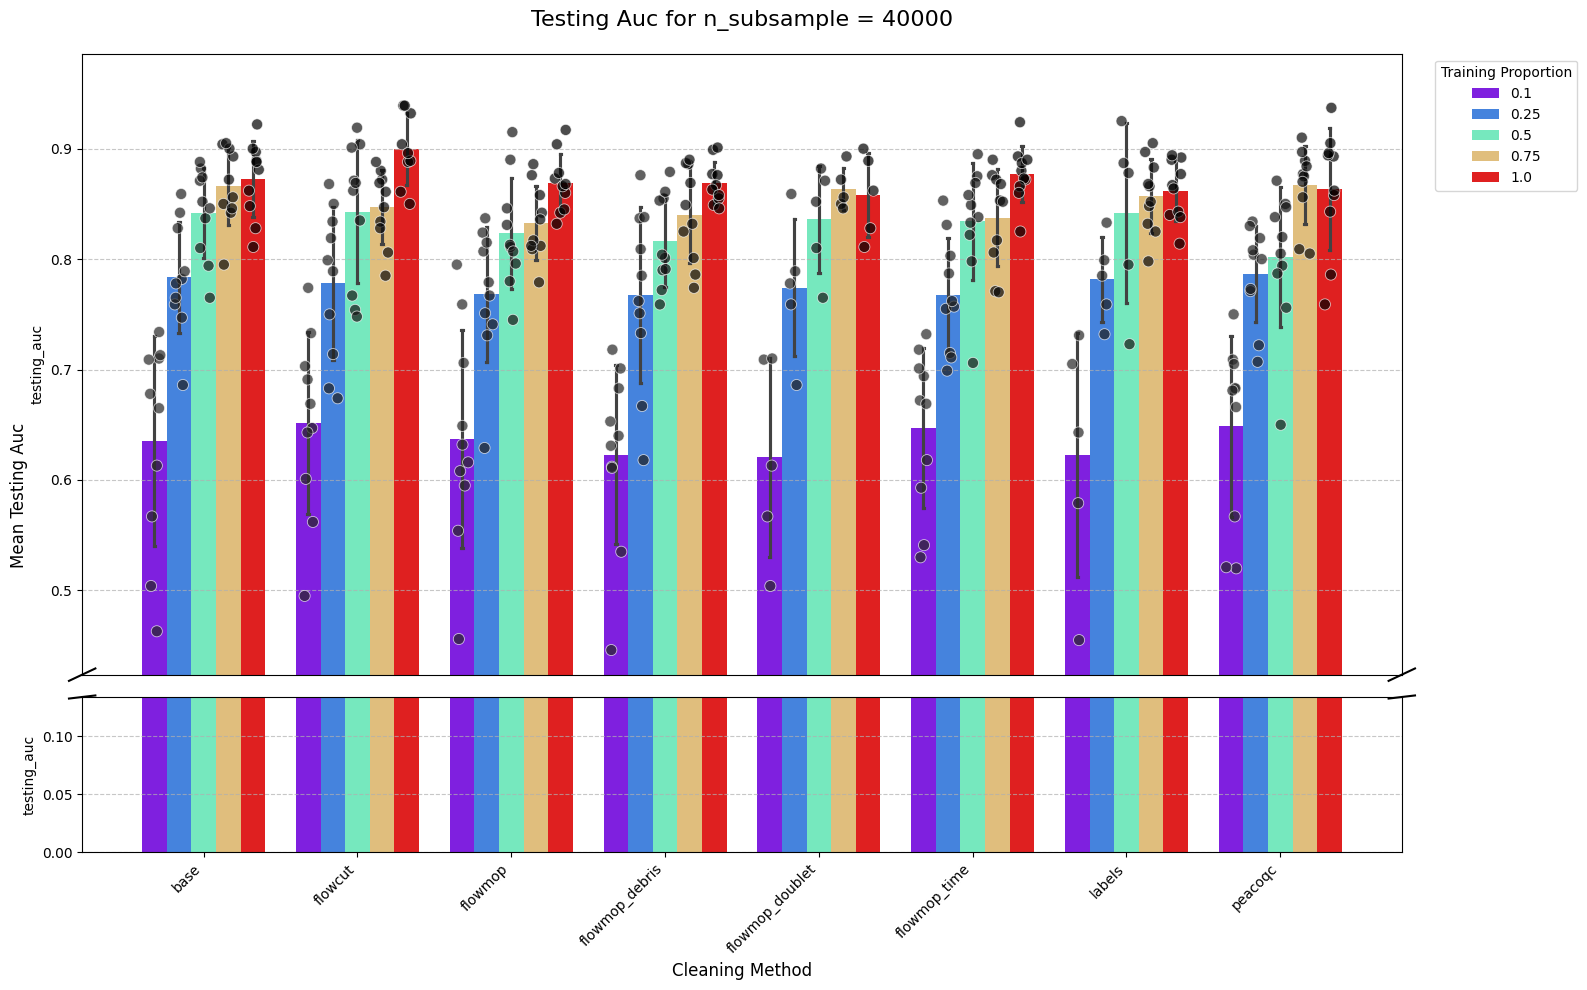

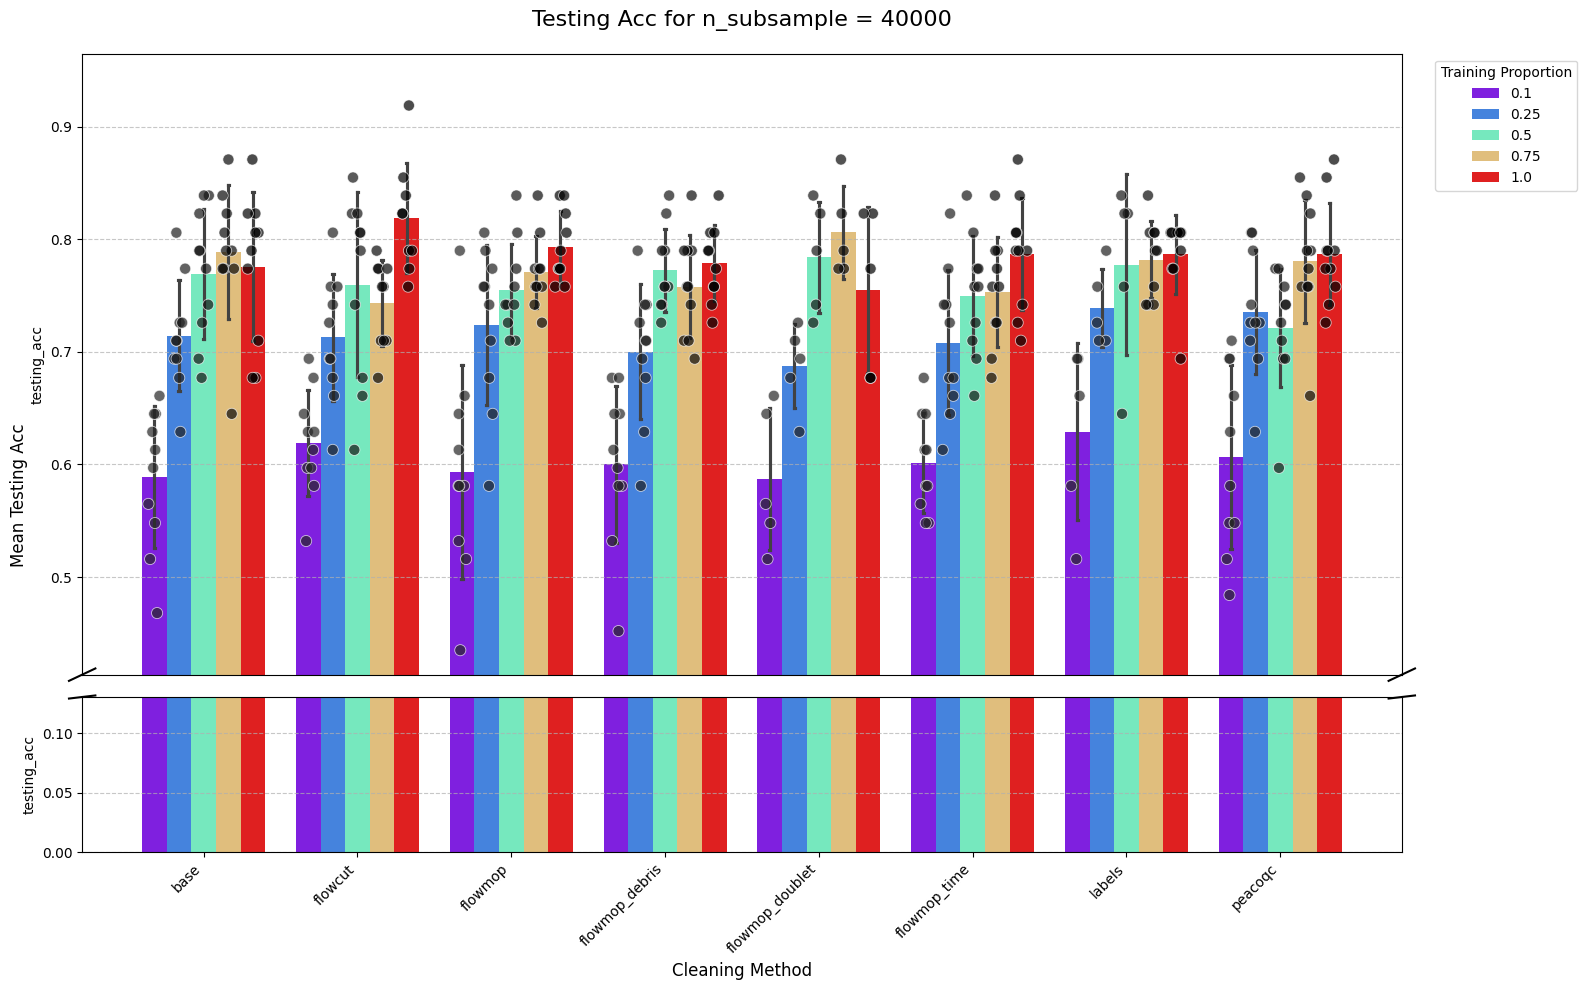

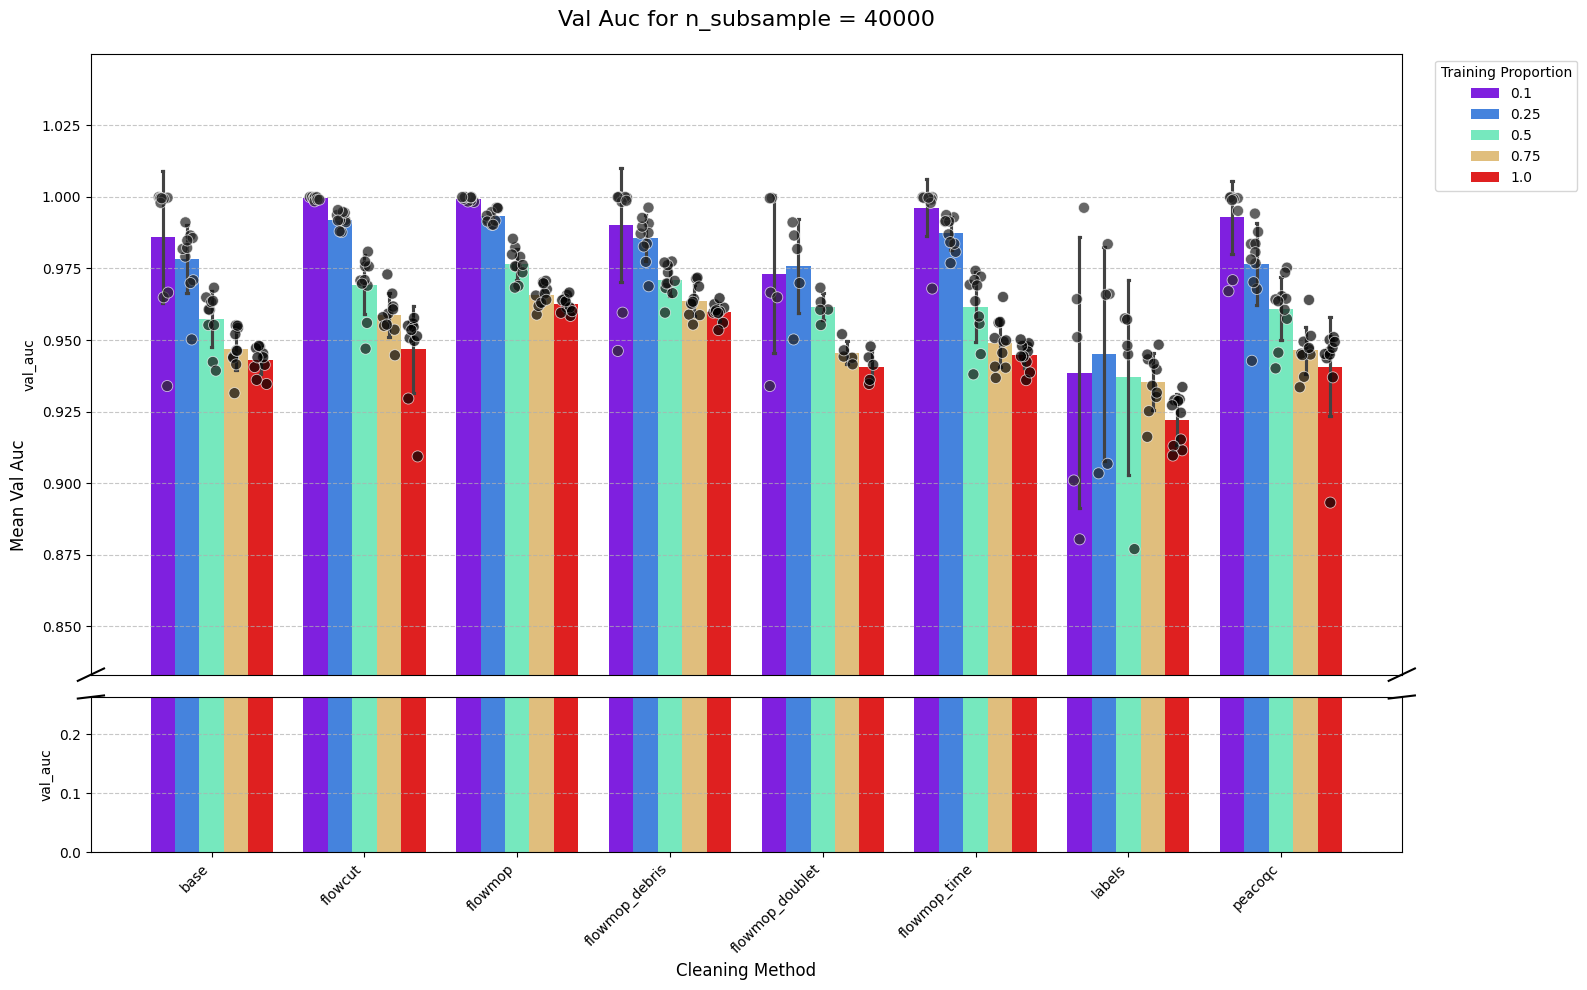

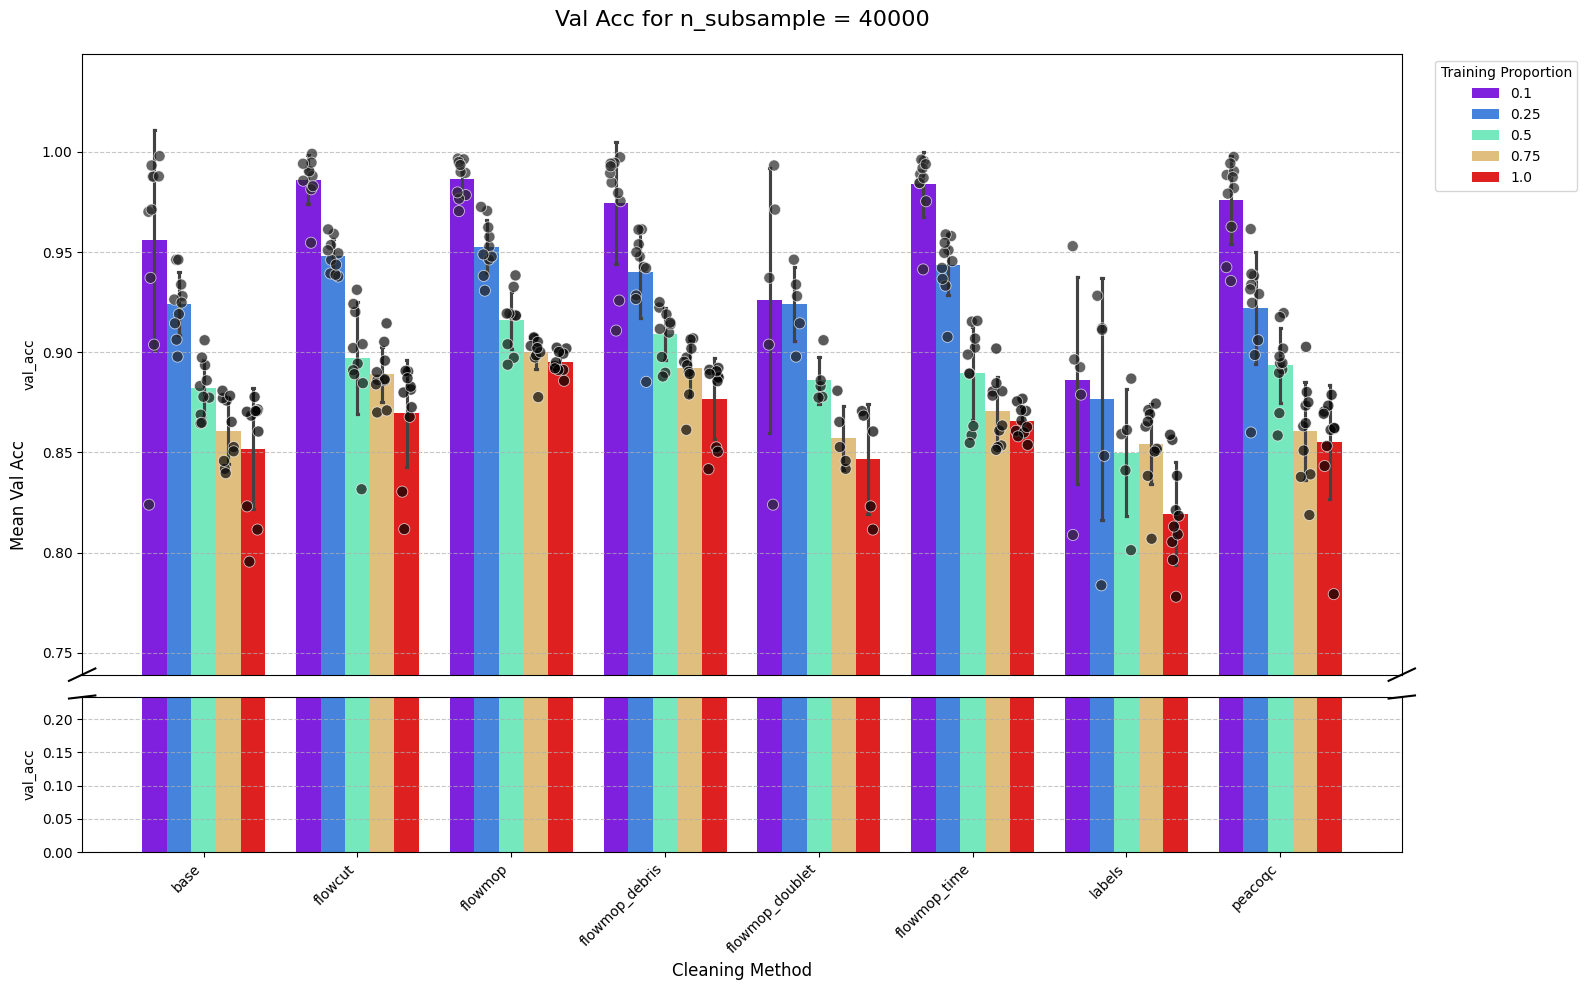

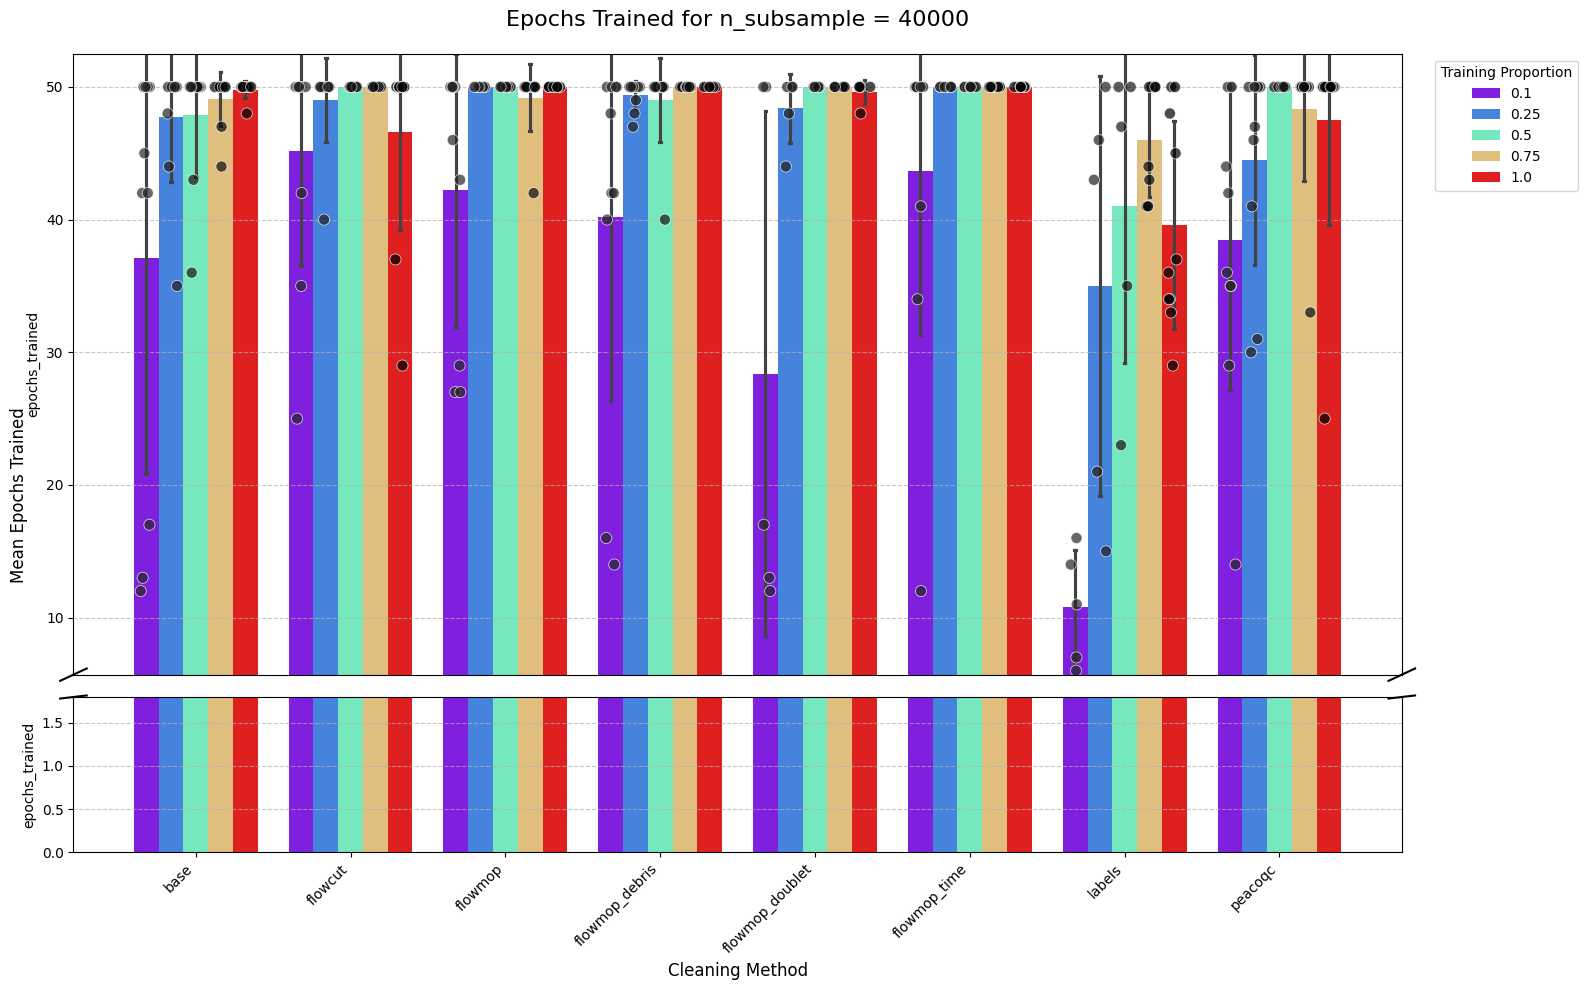

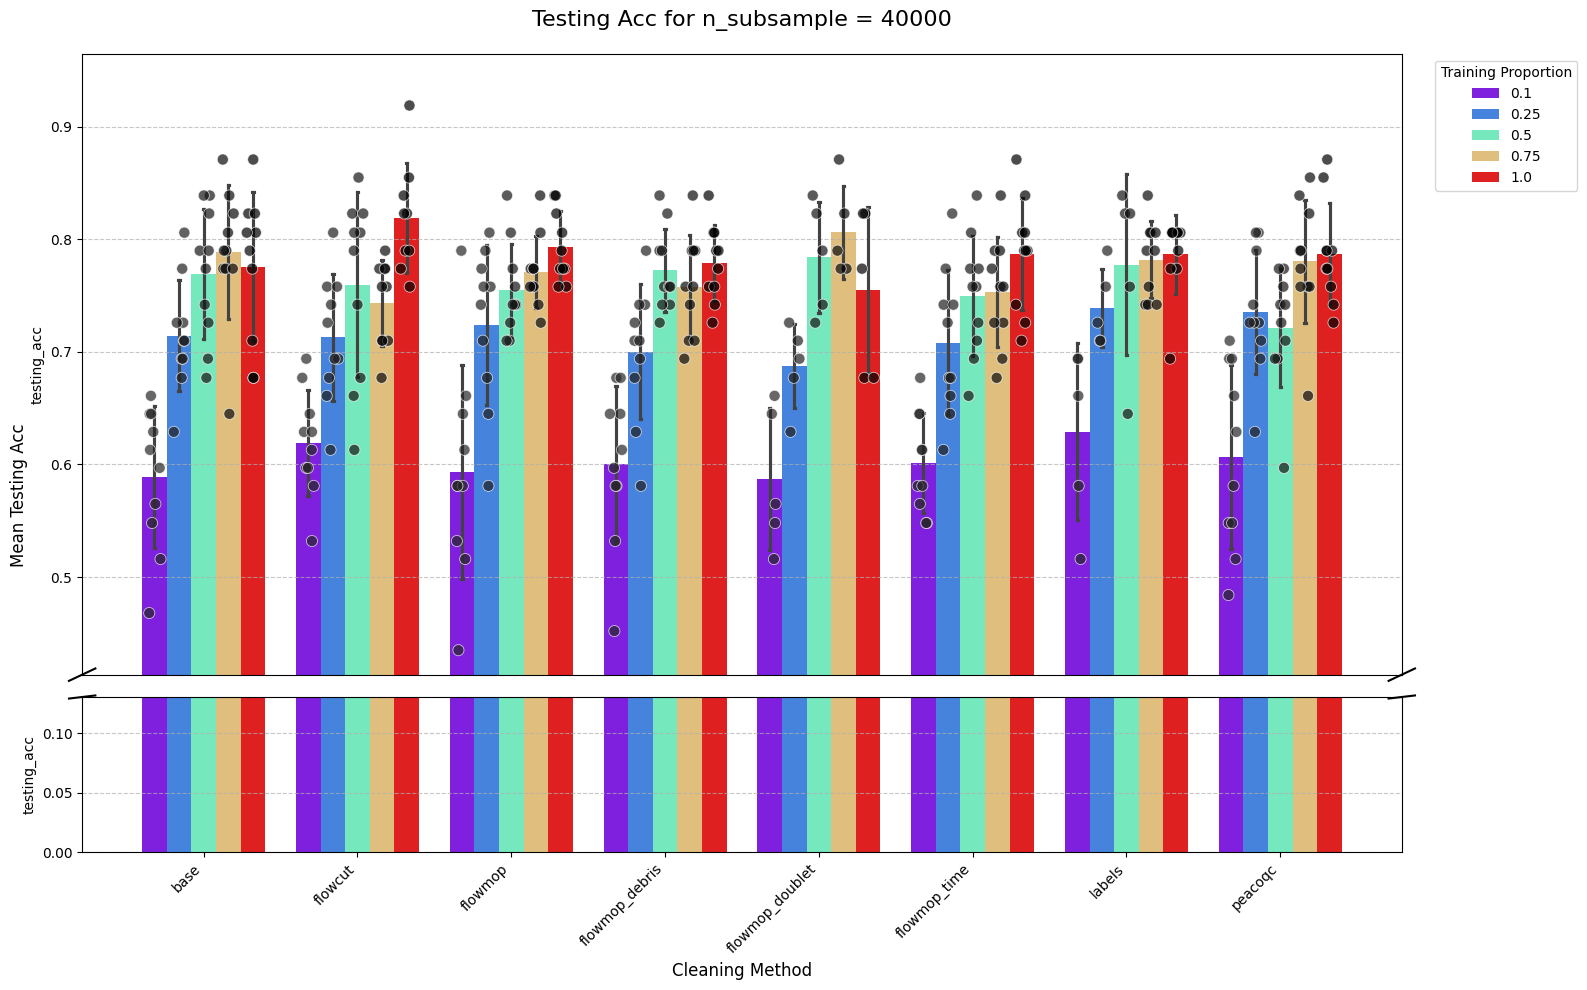

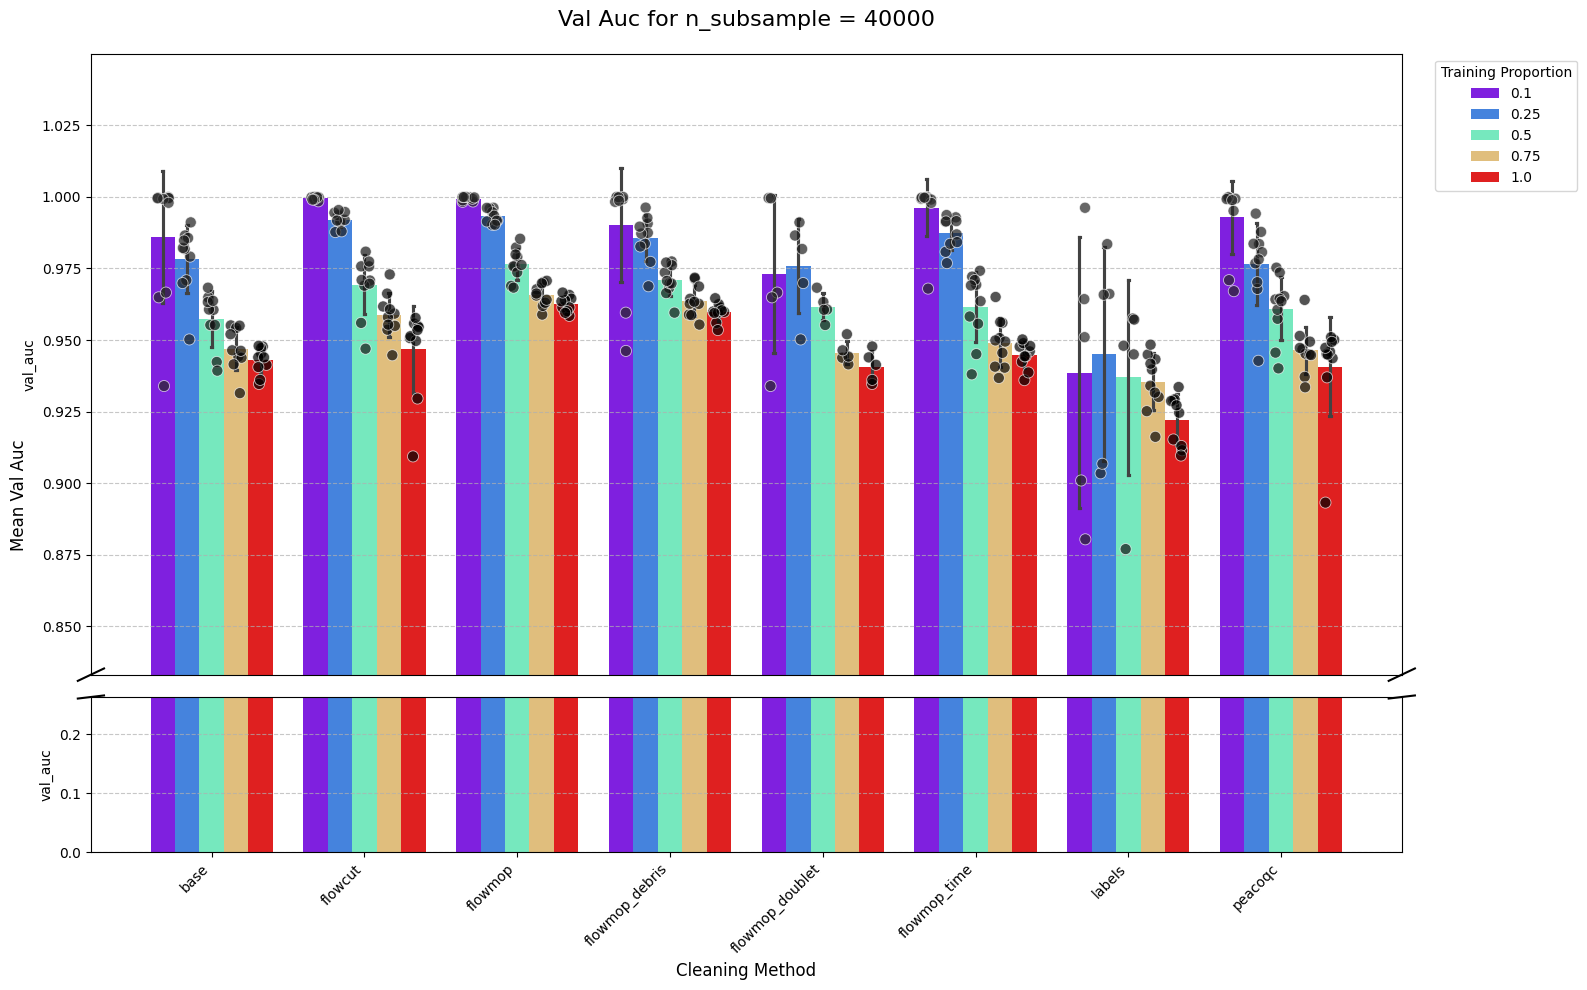

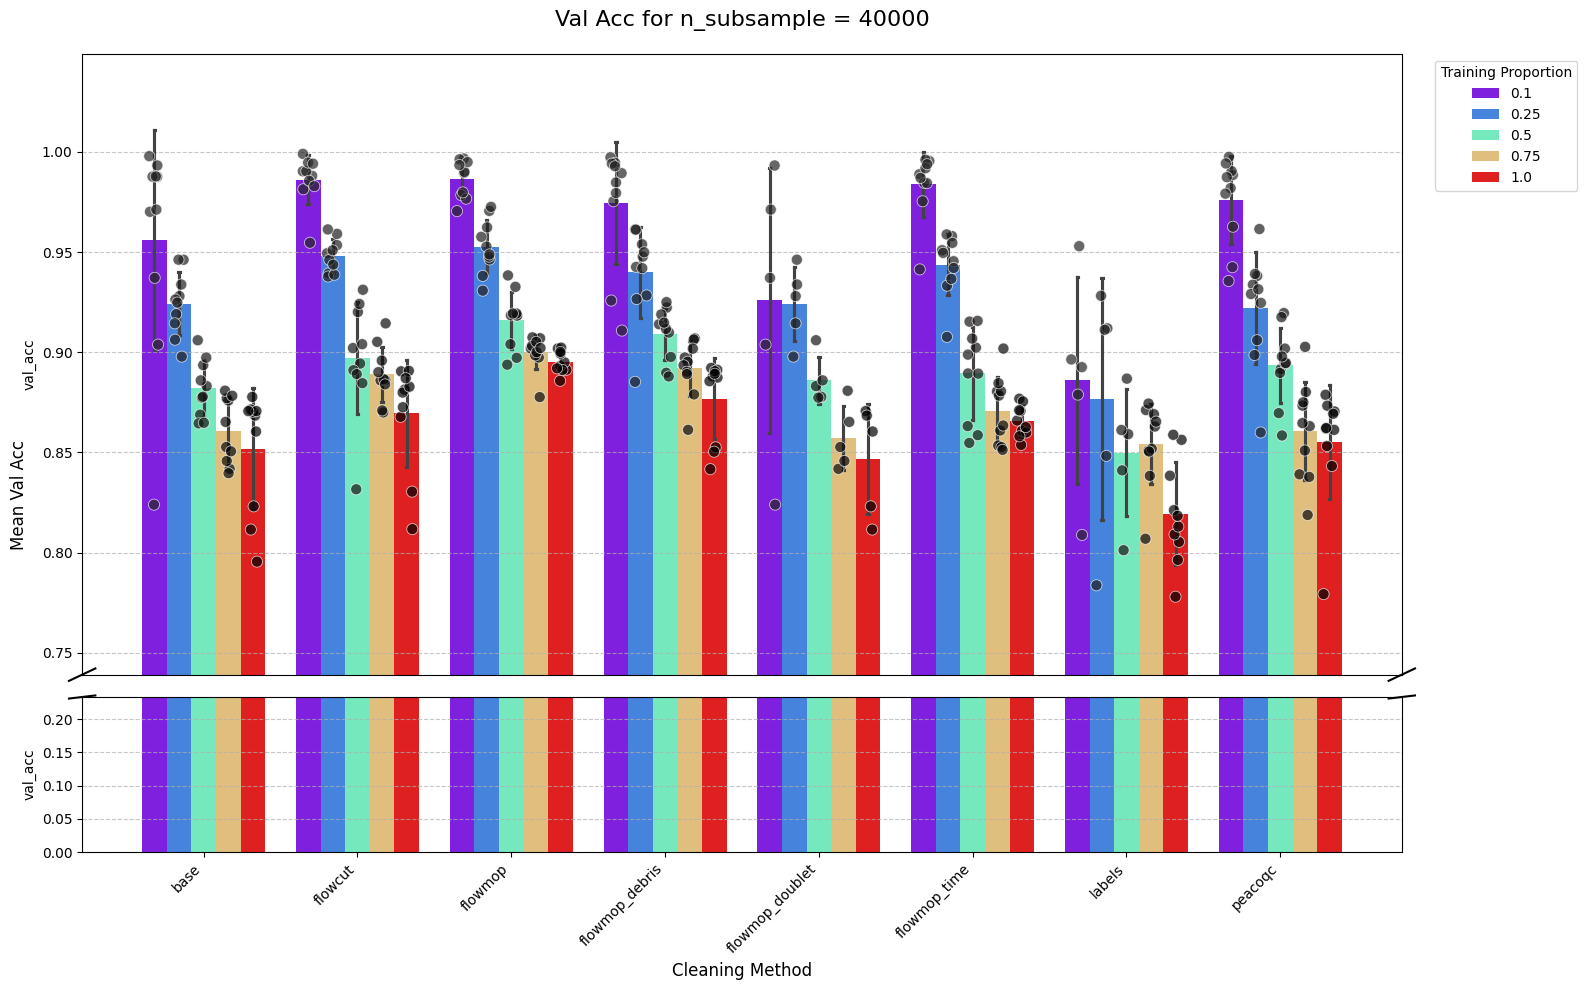

In [220]:

# --- Generate Multi-bar Plots ---
plot_metric_multibar(results, metric='testing_auc', nsubsample=40000)
plot_metric_multibar(results, metric='testing_acc', nsubsample=40000)
plot_metric_multibar(results, metric='val_auc', nsubsample=40000)
plot_metric_multibar(results, metric='val_acc', nsubsample=40000)
plot_metric_multibar(results, metric='epochs_trained', nsubsample=40000)
plot_metric_multibar(results, metric='testing_acc', nsubsample=40000)
plot_metric_multibar(results, metric='val_auc', nsubsample=40000)
plot_metric_multibar(results, metric='val_acc', nsubsample=40000)

In [213]:
import scipy.stats as stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from typing import Optional, Dict, List
import pandas as pd

def perform_anova_and_tukey(
    df: pd.DataFrame, 
    metric: str, 
    nsubsample: int, 
    training_proportion: float,
    alpha: float = 0.05
) -> Optional[pd.DataFrame]:
    """Performs a one-way ANOVA and a Tukey HSD post-hoc test.

    This function filters for a specific training proportion and n_subsample,
    runs an ANOVA, and if significant, performs a Tukey HSD test.

    Args:
        df (pd.DataFrame): The dataframe with experiment results.
        metric (str): The metric to be tested (e.g., 'testing_auc').
        nsubsample (int): The subsample size to filter by.
        training_proportion (float): The training proportion to filter by.
        alpha (float, optional): The significance level. Defaults to 0.05.
        
    Returns:
        An optional DataFrame with significant Tukey HSD results, or None.
    """
    subset = df[(df['nsubsample'] == nsubsample) & 
                (df['training_proportion'] == training_proportion) & 
                (df[metric].notna())].copy()

    groups = subset.groupby('cleaning_method')[metric].apply(list)
    
    if len(groups) < 2:
        return None

    # One-way ANOVA
    _, p_val = stats.f_oneway(*groups)
    
    tukey_results = pairwise_tukeyhsd(
        endog=subset[metric], 
        groups=subset['cleaning_method'], 
        alpha=alpha
    )
    
    results_df = pd.DataFrame(data=tukey_results._results_table.data[1:], columns=tukey_results._results_table.data[0])
    significant_results = results_df[results_df['reject'] == True]

    return significant_results if not significant_results.empty else None

In [216]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import List, Dict

def add_stat_annotation(
    ax, 
    df_plot: pd.DataFrame,
    metric: str,
    order: List[str],
    hue_order: List[float],
    tukey_results: pd.DataFrame,
    training_prop: float,
    all_annotations: List[Dict]
):
    """
    Adds statistical annotation brackets with robust collision avoidance.
    
    This function tracks all annotations drawn on the plot to prevent overlaps,
    both within a single hue and across different hues.
    """
    if tukey_results is None or tukey_results.empty:
        return

    # --- Initial Setup ---
    num_hues = len(hue_order)
    bar_width = ax.patches[0].get_width() if ax.patches else 0.8
    hue_pos = {prop: i for i, prop in enumerate(hue_order)}
    offset = (hue_pos[training_prop] - (num_hues - 1) / 2) * bar_width
    
    data_for_hue = df_plot[df_plot['training_proportion'] == training_prop]
    y_max_hue = data_for_hue.groupby('cleaning_method')[metric].max()

    # --- Vertical Step Calculation ---
    # Use axis range for a more stable step size
    y_min, y_max = ax.get_ylim()
    y_step = (y_max - y_min) * 0.035
    if y_step == 0:
        y_step = 0.03 # Fallback value

    # Sort pairs by distance to draw shorter brackets first (heuristic for cleaner plots)
    tukey_results['dist'] = tukey_results.apply(
        lambda row: abs(order.index(row['group1']) - order.index(row['group2'])),
        axis=1
    )
    sorted_results = tukey_results.sort_values('dist')

    for _, row in sorted_results.iterrows():
        group1, group2, p_adj = row['group1'], row['group2'], row['p-adj']
        
        if group1 not in order or group2 not in order: continue
            
        cat_idx1, cat_idx2 = order.index(group1), order.index(group2)
        x_start, x_end = min(cat_idx1, cat_idx2) + offset, max(cat_idx1, cat_idx2) + offset
        
        y_bar_max = max(y_max_hue.get(group1, 0), y_max_hue.get(group2, 0))

        # --- Collision Detection ---
        # Find the highest level of any existing annotation this one would cross
        max_y_colliding = 0
        for ann in all_annotations:
            # Check for horizontal overlap: (start1 < end2) and (start2 < end1)
            if (x_start < ann['x_end']) and (ann['x_start'] < x_end):
                if ann['y_pos'] > max_y_colliding:
                    max_y_colliding = ann['y_pos']
        
        # --- Position Calculation (Improved) ---
        # The new annotation must be placed above the highest colliding one.
        # It also must be placed above the bars it spans.
        y_from_collision = max_y_colliding + y_step if max_y_colliding > 0 else 0
        y_from_bar = y_bar_max + y_step * 1.5
        
        y = max(y_from_collision, y_from_bar)

        # --- Drawing ---
        ax.plot([x_start, x_start, x_end, x_end], [y, y + y_step * 0.2, y + y_step * 0.2, y], lw=1.5, c='k')
        p_text = f"p={p_adj:.2f}" if p_adj >= 0.01 else "p<0.01"
        ax.text((x_start + x_end) / 2, y + y_step * 0.3, p_text, ha='center', va='bottom', color='k', fontsize=9)

        # Record this annotation's position and span for future collision checks
        all_annotations.append({'x_start': x_start, 'x_end': x_end, 'y_pos': y})


def plot_metric_with_stats(
    df: pd.DataFrame, 
    metric: str, 
    nsubsample: int,
    tukey_results_by_prop: Dict[float, pd.DataFrame]
):
    """Generates a bar plot with statistical annotations."""
    plt.figure(figsize=(20, 12)) # Increased figure height
    
    data_to_plot = df[df['nsubsample'] == nsubsample].copy()
    if data_to_plot.empty:
        print(f"No data to plot for nsubsample={nsubsample}, metric={metric}")
        return
        
    sorted_methods = sorted(data_to_plot['cleaning_method'].dropna().unique())
    hue_order = sorted(data_to_plot['training_proportion'].unique())

    ax = sns.barplot(
        data=data_to_plot, x='cleaning_method', y=metric, hue='training_proportion',
        palette='rainbow', errorbar='sd', capsize=0.05, order=sorted_methods, hue_order=hue_order
    )
    sns.stripplot(
        data=data_to_plot, x='cleaning_method', y=metric, hue='training_proportion',
        dodge=True, color='black', linewidth=0.6, size=4, alpha=0.7, ax=ax, 
        order=sorted_methods, hue_order=hue_order
    )
    
    # This list will be shared across all calls to add_stat_annotation for this plot
    all_annotations = []
    
    # The order of the loop matters for layering.
    # Plotting annotations for hue groups further from the center first can sometimes look better.
    # Here, we sort by distance from the center of the hue cluster.
    center_hue_index = (len(hue_order) - 1) / 2
    sorted_hue_order = sorted(hue_order, key=lambda p: abs(hue_order.index(p) - center_hue_index), reverse=True)

    for prop in sorted_hue_order:
        if prop in tukey_results_by_prop:
            add_stat_annotation(ax, data_to_plot, metric, sorted_methods, hue_order, tukey_results_by_prop[prop], prop, all_annotations)

    plt.title(f'{metric.replace("_", " ").title()} for n_subsample = {nsubsample}', fontsize=18)
    plt.xlabel('Cleaning Method', fontsize=14)
    plt.ylabel(f'Mean {metric.replace("_", " ").title()}', fontsize=14)
    plt.xticks(rotation=45, ha='right', fontsize=12)
    plt.yticks(fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(
        handles[:len(hue_order)], labels[:len(hue_order)], title='Training Proportion', 
        bbox_to_anchor=(1.02, 1), loc='upper left'
    )
    
    # Dynamically adjust y-axis limit based on the highest annotation
    if all_annotations:
        y_range = df[metric].max() - df[metric].min()
        y_step = y_range * 0.05 if y_range > 0 else 0.05
        max_ann_y = max(ann['y_pos'] for ann in all_annotations)
        y_min, _ = ax.get_ylim()
        # Add extra padding to the top
        ax.set_ylim(y_min, max_ann_y + 4 * y_step)
    
    plt.tight_layout(rect=[0, 0, 0.9, 1])
    plt.show()


C:\Users\Tony\AppData\Local\Temp\ipykernel_18372\1992747989.py:32: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = subset.groupby('cleaning_method')[metric].apply(list)
C:\Users\Tony\AppData\Local\Temp\ipykernel_18372\2733357843.py:105: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


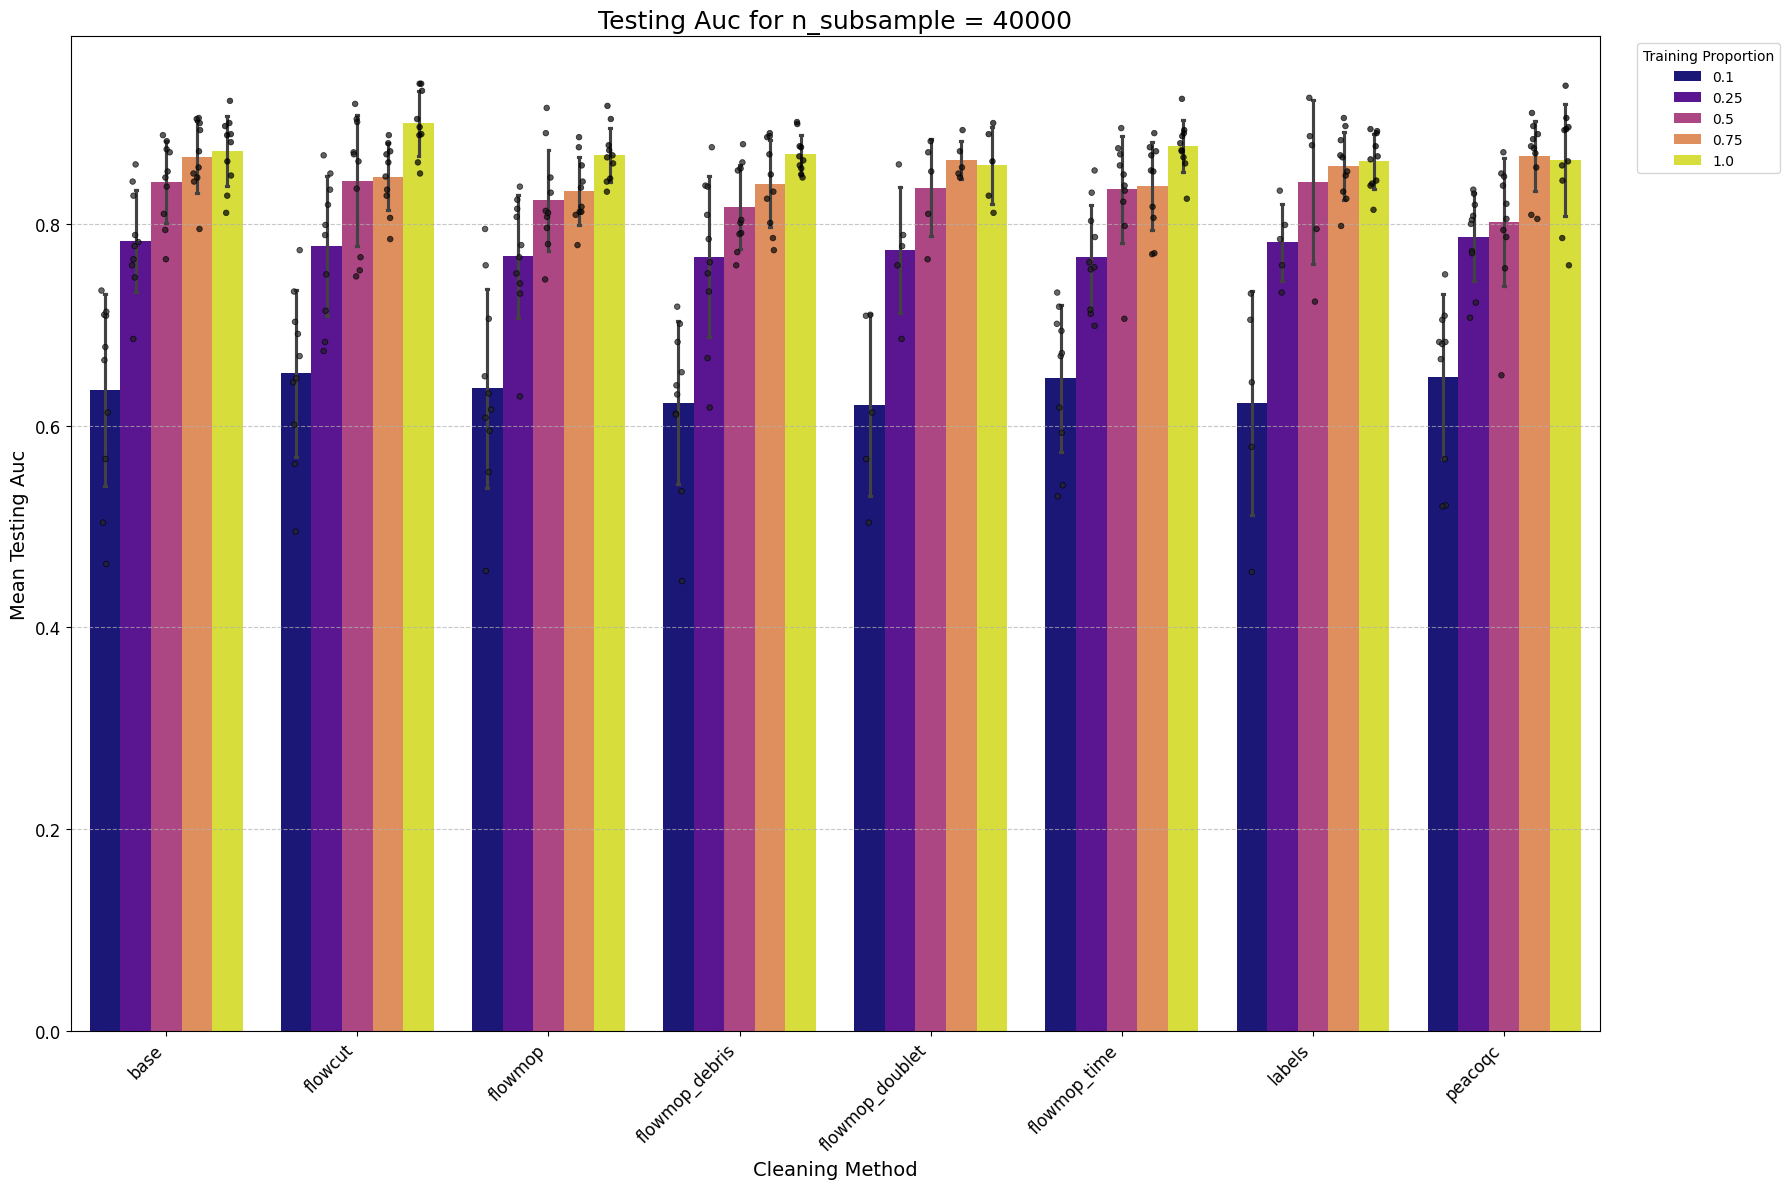

C:\Users\Tony\AppData\Local\Temp\ipykernel_18372\1992747989.py:32: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = subset.groupby('cleaning_method')[metric].apply(list)
C:\Users\Tony\AppData\Local\Temp\ipykernel_18372\2733357843.py:105: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


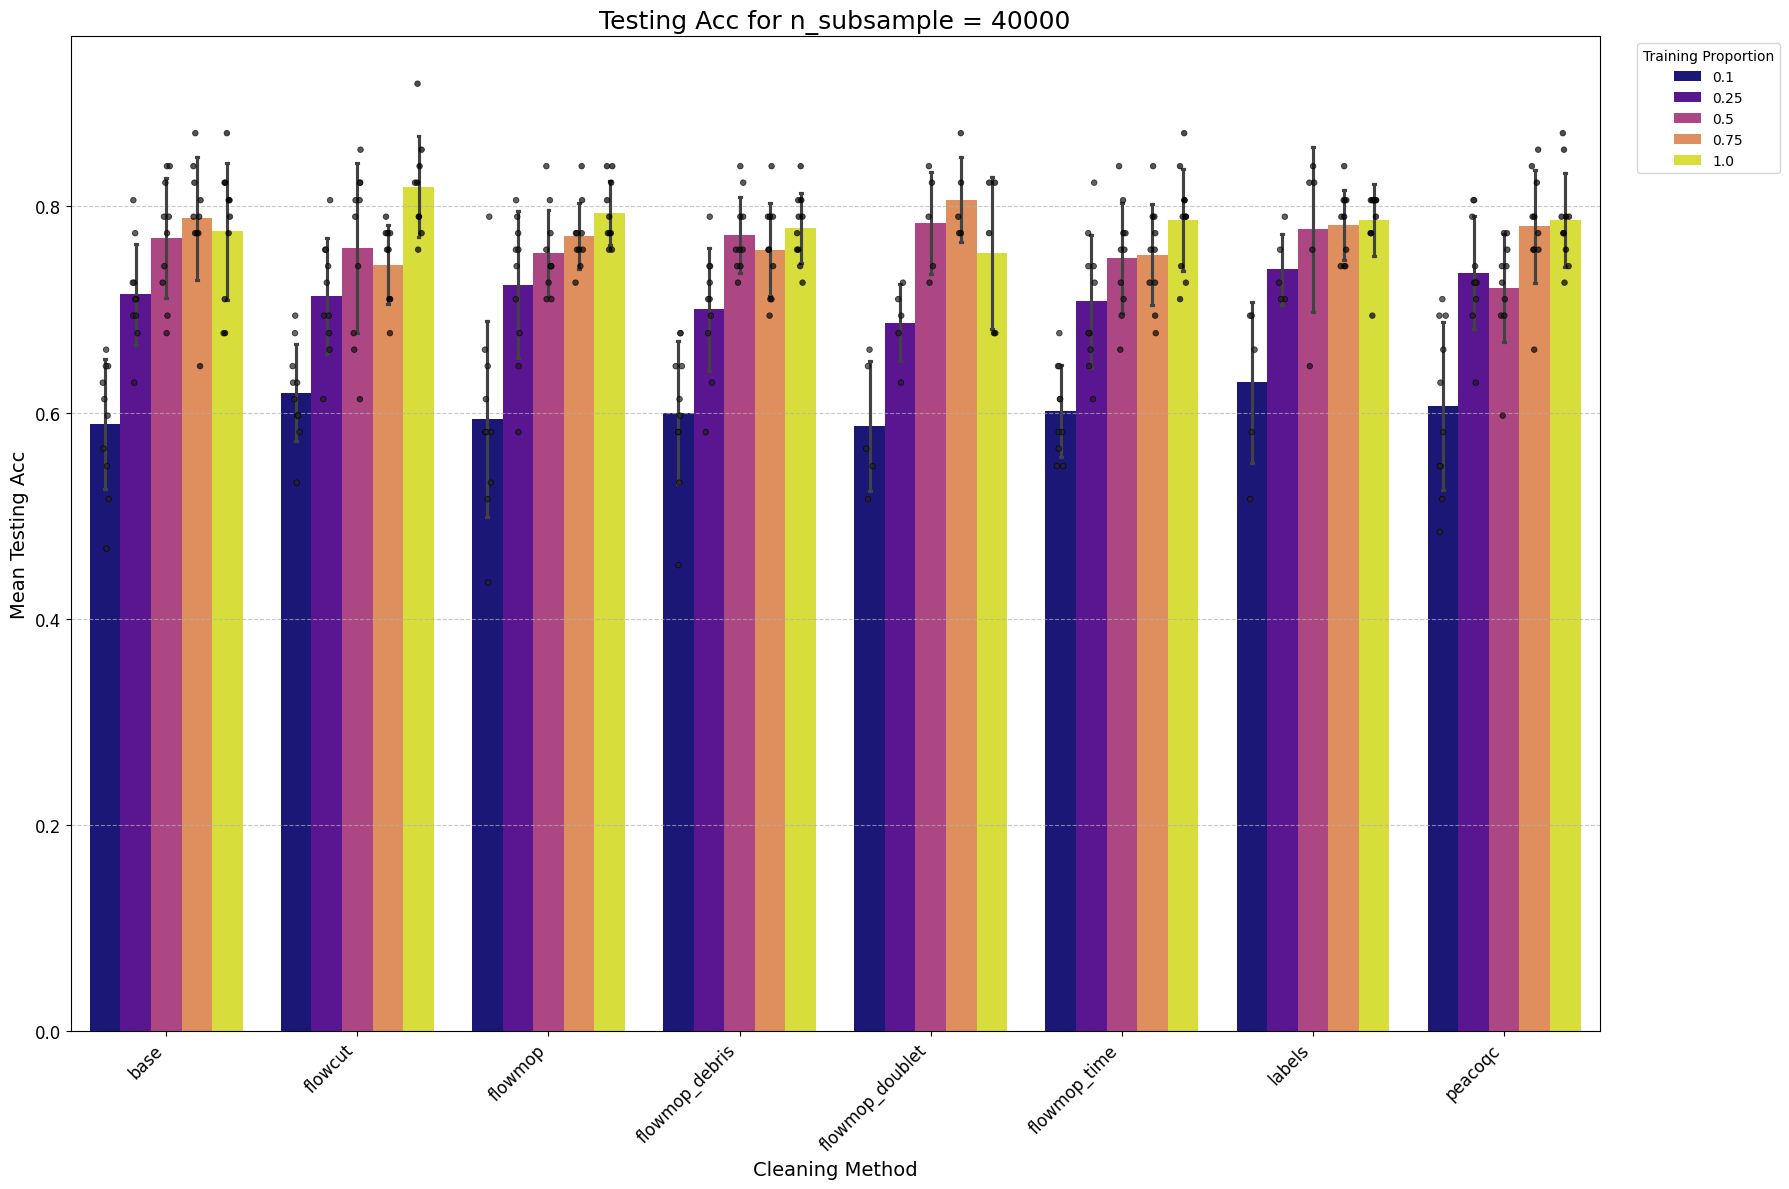

C:\Users\Tony\AppData\Local\Temp\ipykernel_18372\1992747989.py:32: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = subset.groupby('cleaning_method')[metric].apply(list)
C:\Users\Tony\AppData\Local\Temp\ipykernel_18372\2733357843.py:105: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(
C:\Users\Tony\AppData\Local\Temp\ipykernel_18372\2733357843.py:32: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  y_max_hue = data_for_hue.groupby('cleaning_method')[metric].max()
C:\Users\Tony\AppData\Lo

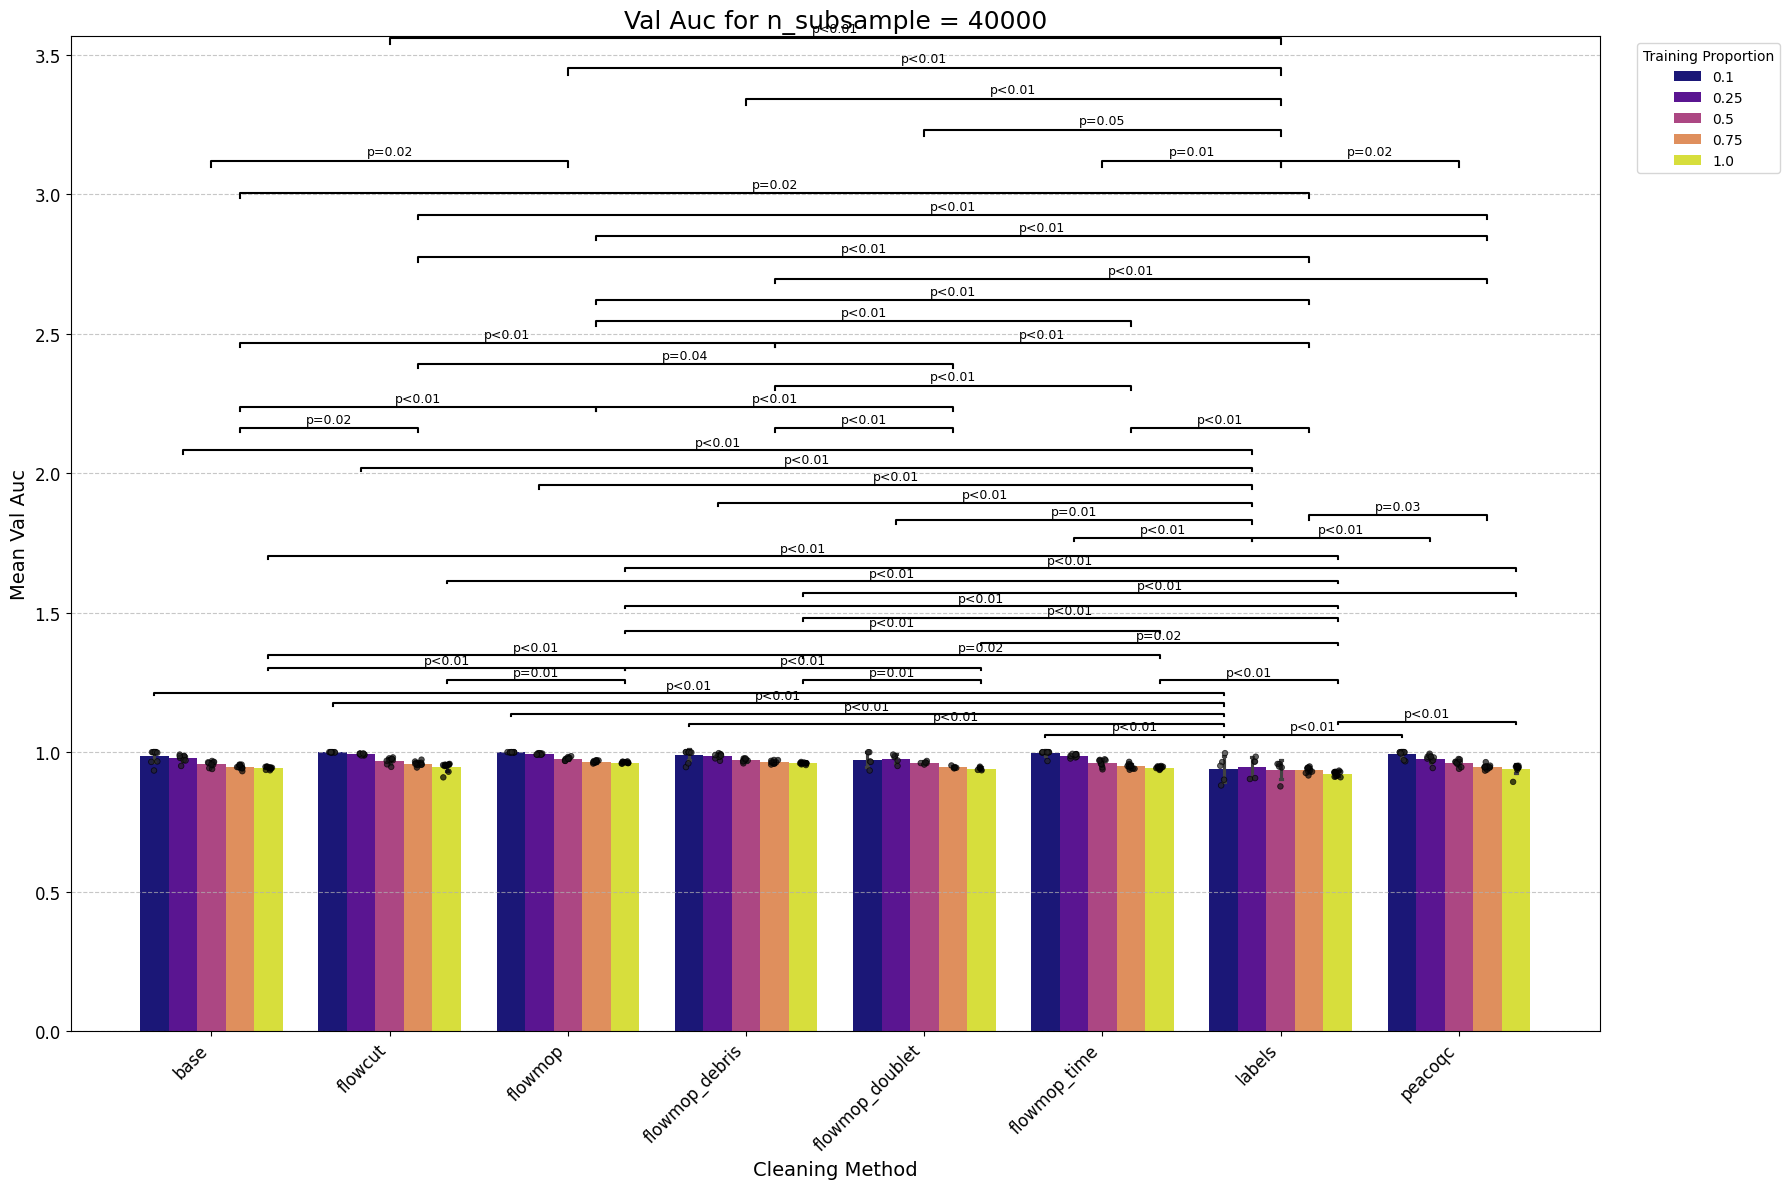

C:\Users\Tony\AppData\Local\Temp\ipykernel_18372\1992747989.py:32: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = subset.groupby('cleaning_method')[metric].apply(list)
C:\Users\Tony\AppData\Local\Temp\ipykernel_18372\2733357843.py:105: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(
C:\Users\Tony\AppData\Local\Temp\ipykernel_18372\2733357843.py:32: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  y_max_hue = data_for_hue.groupby('cleaning_method')[metric].max()
C:\Users\Tony\AppData\Lo

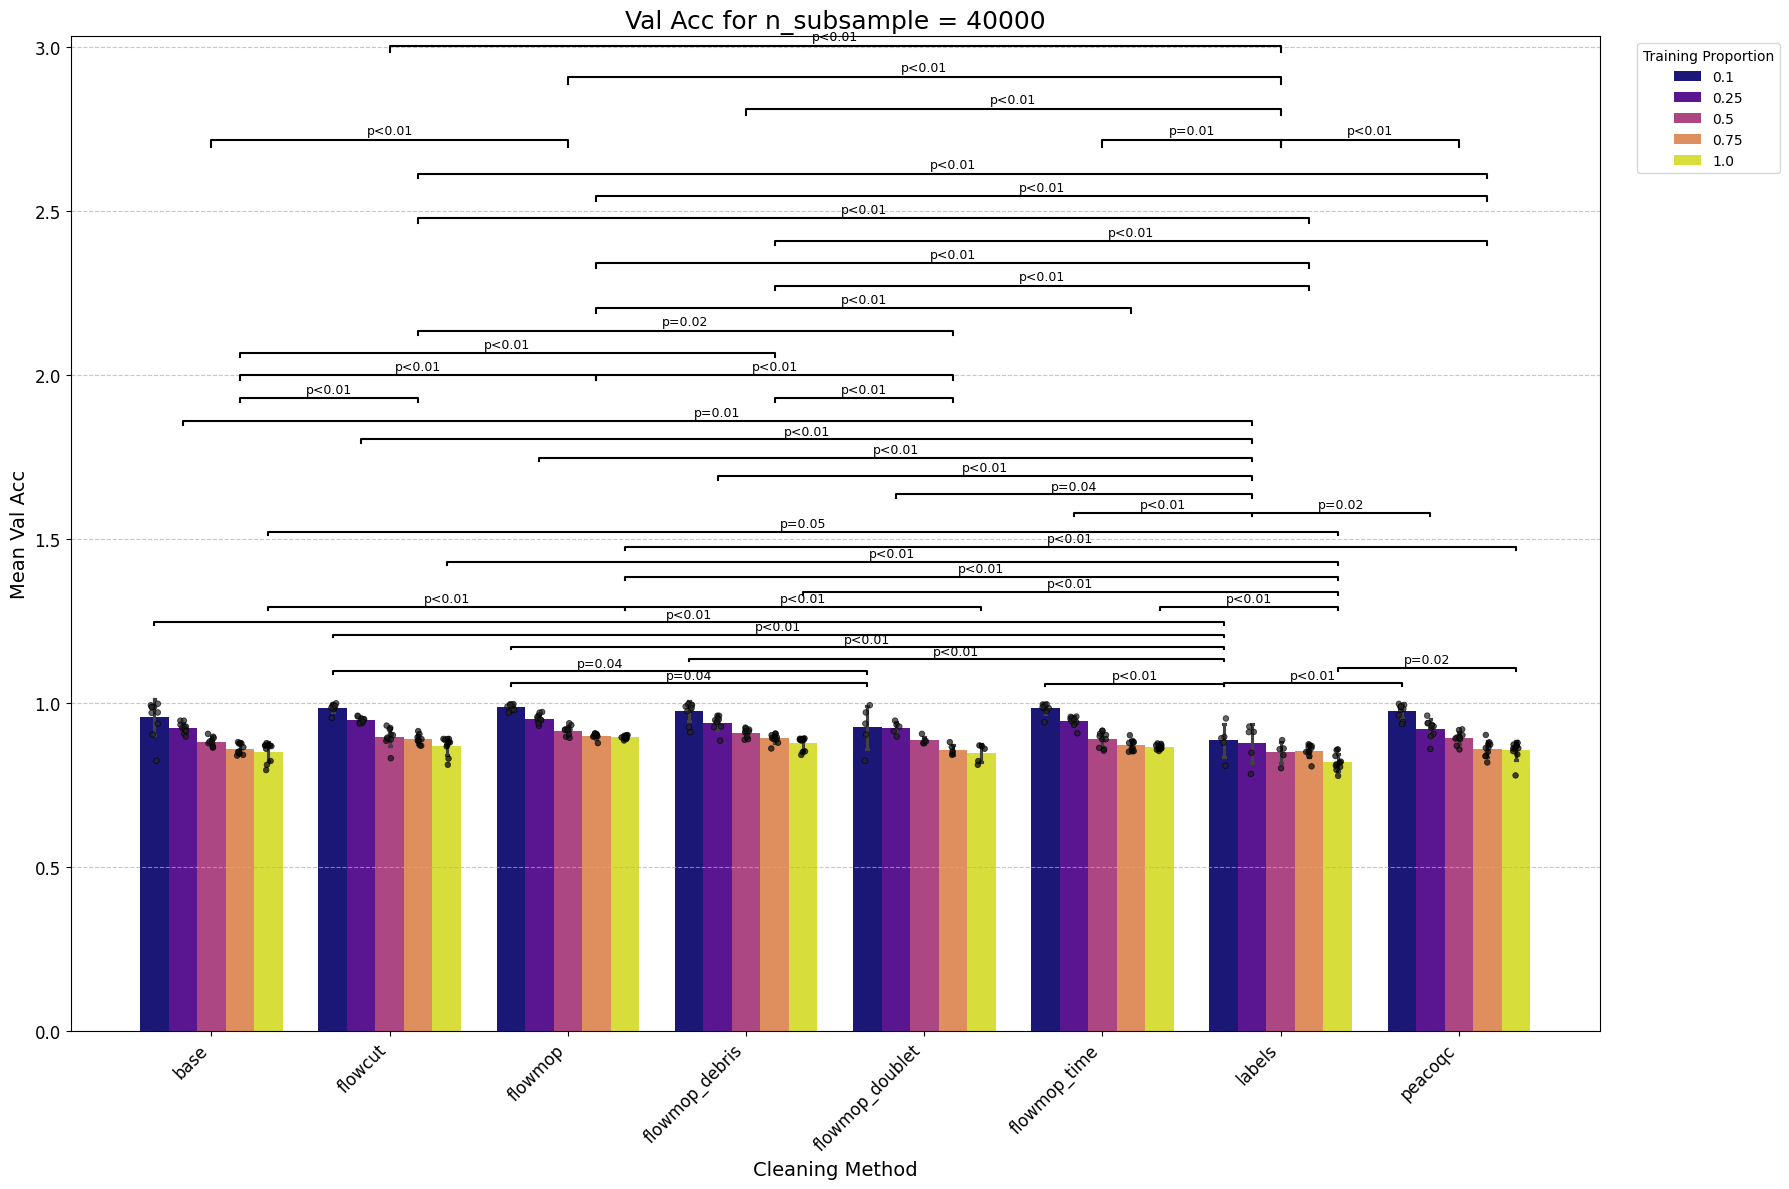

C:\Users\Tony\AppData\Local\Temp\ipykernel_18372\1992747989.py:32: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = subset.groupby('cleaning_method')[metric].apply(list)
C:\Users\Tony\AppData\Local\Temp\ipykernel_18372\2733357843.py:105: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


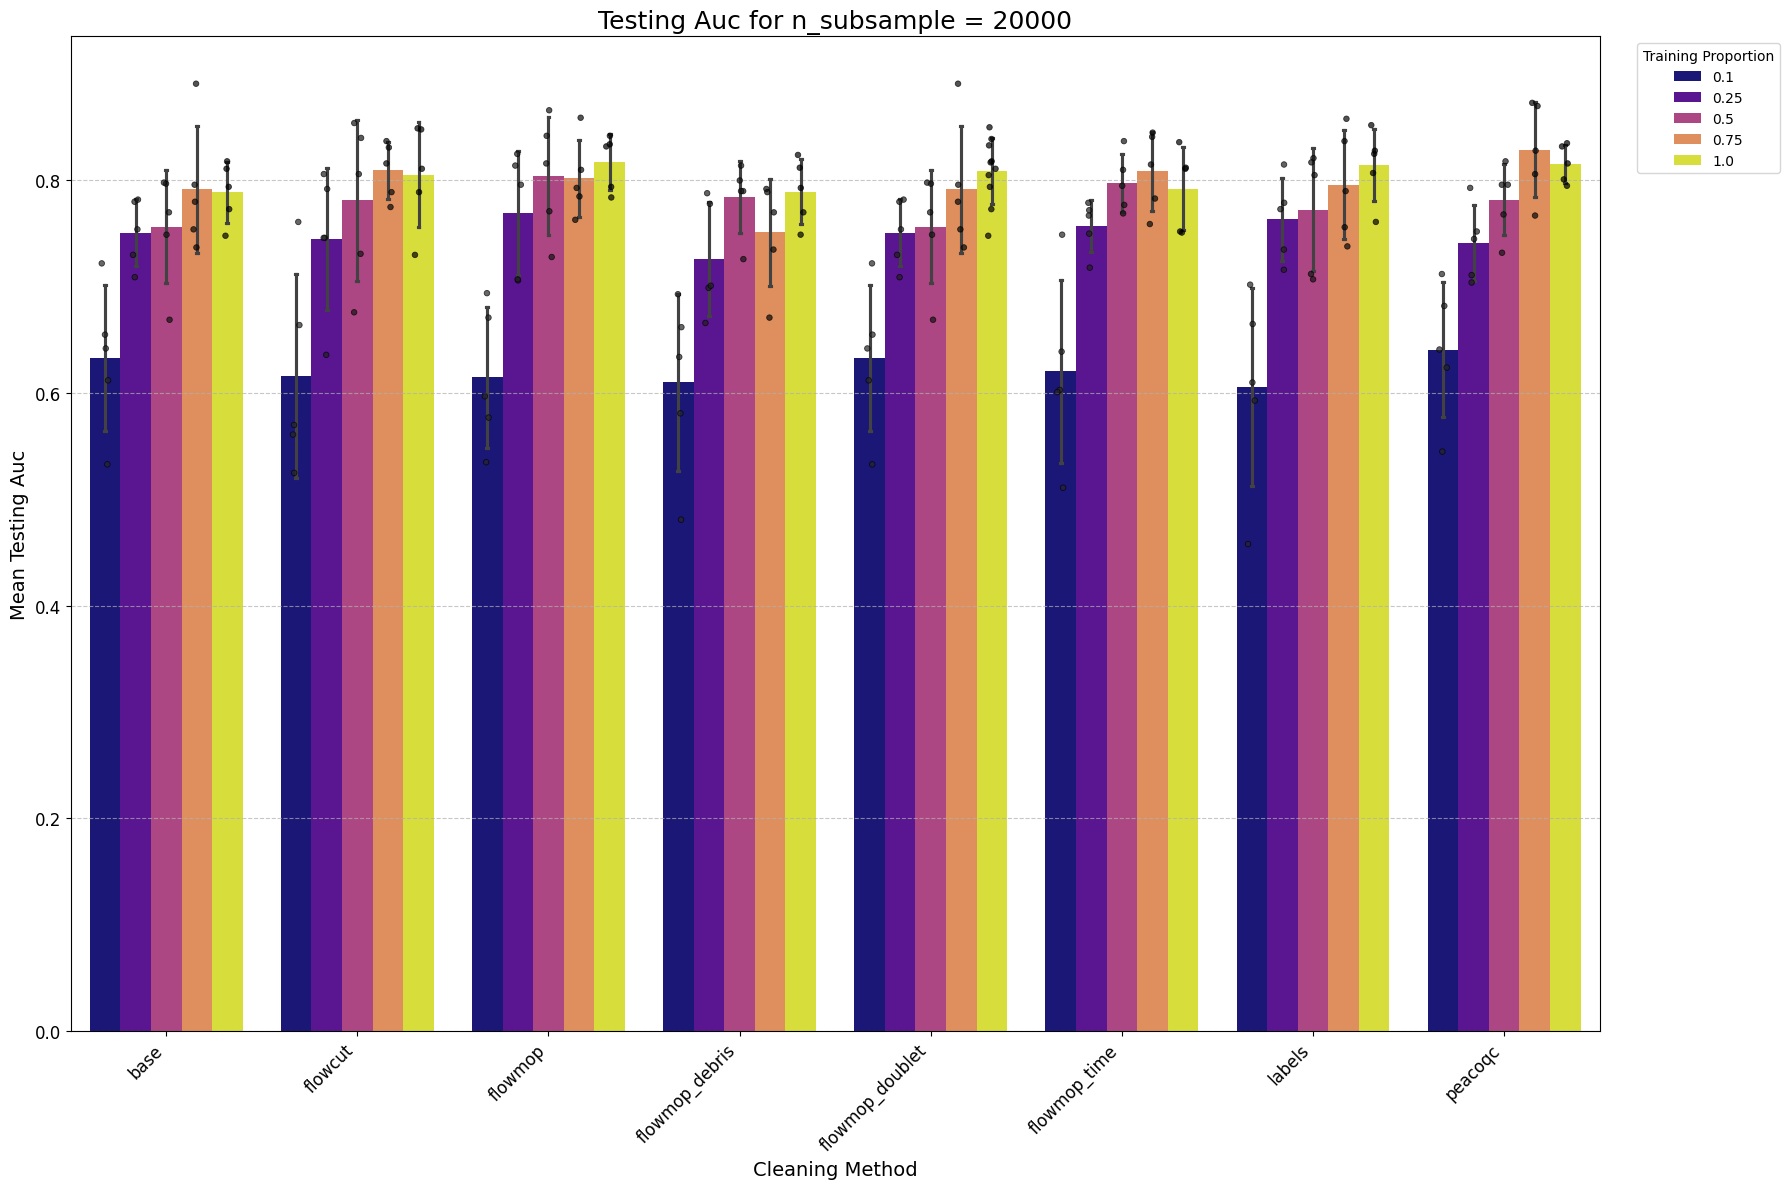

C:\Users\Tony\AppData\Local\Temp\ipykernel_18372\1992747989.py:32: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = subset.groupby('cleaning_method')[metric].apply(list)
C:\Users\Tony\AppData\Local\Temp\ipykernel_18372\2733357843.py:105: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


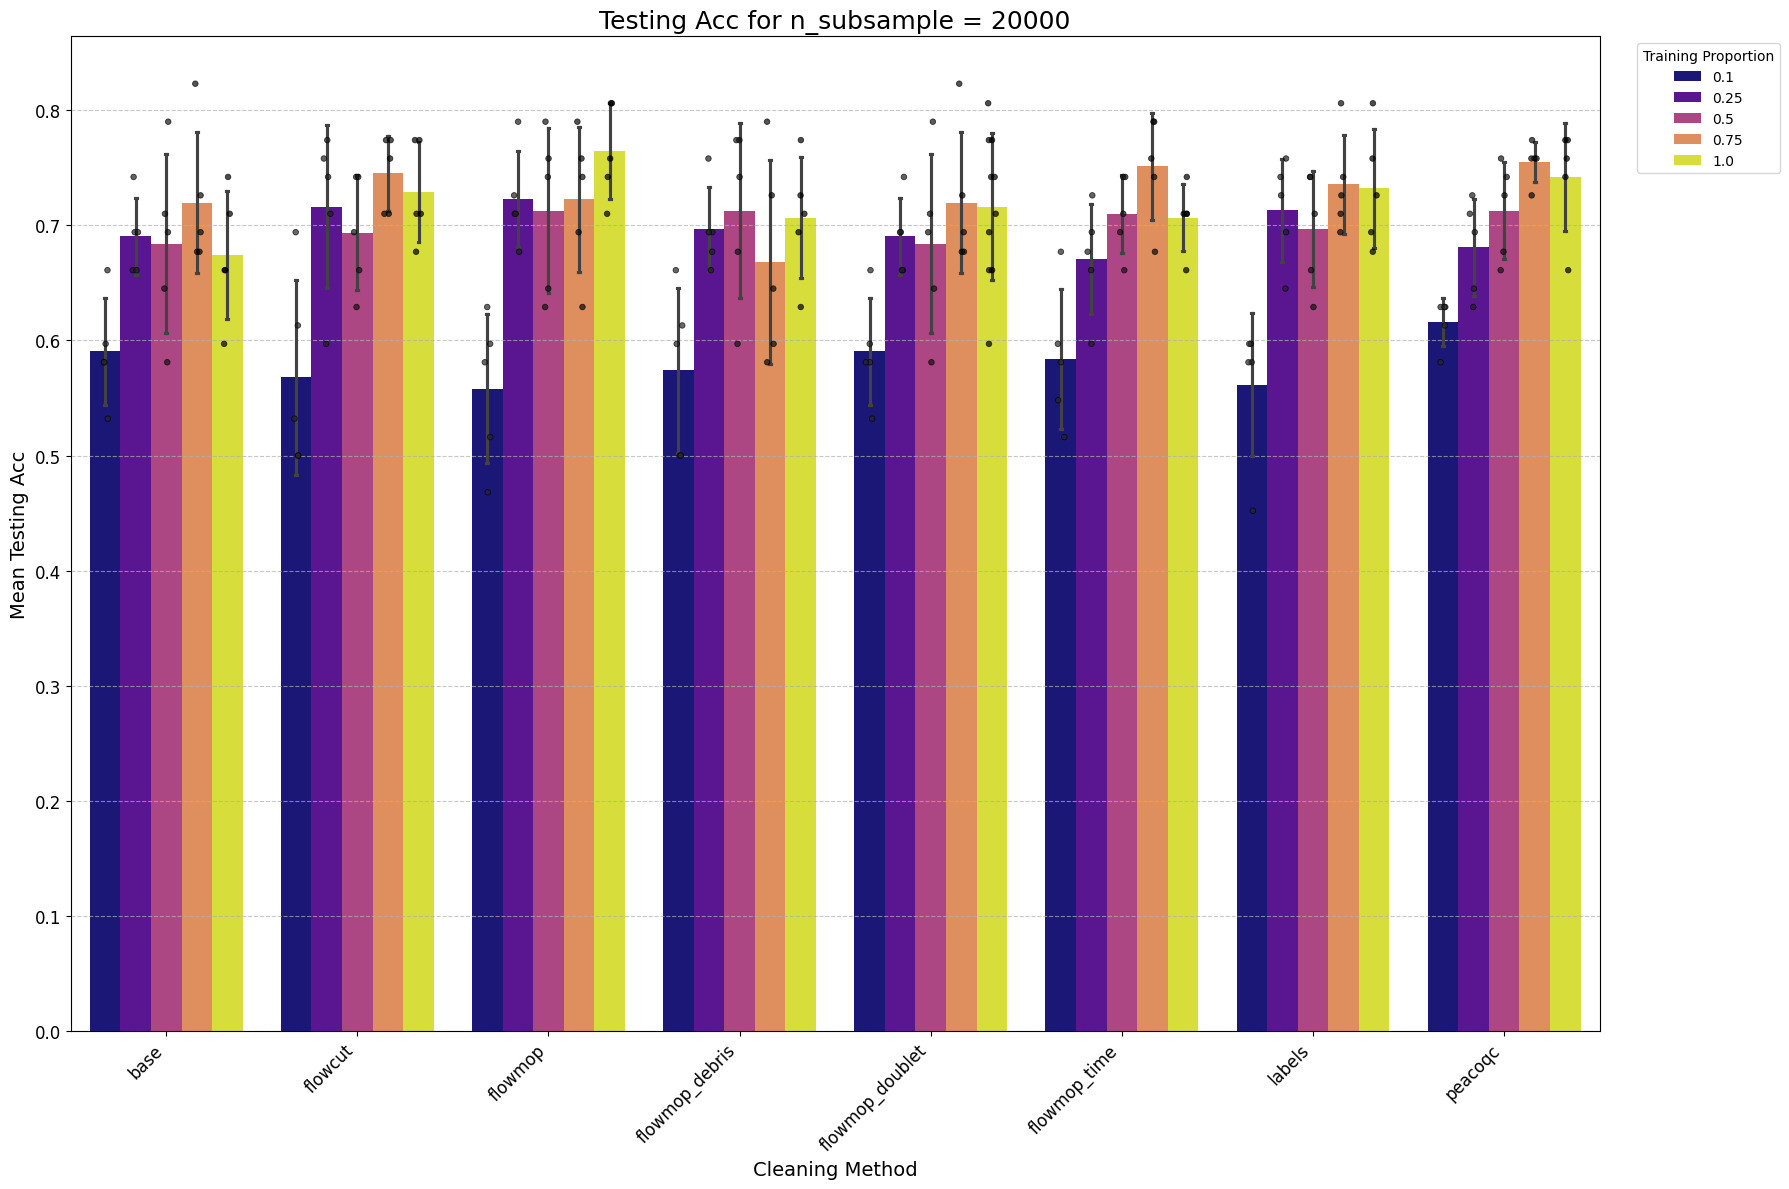

C:\Users\Tony\AppData\Local\Temp\ipykernel_18372\1992747989.py:32: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = subset.groupby('cleaning_method')[metric].apply(list)
C:\Users\Tony\AppData\Local\Temp\ipykernel_18372\2733357843.py:105: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(
C:\Users\Tony\AppData\Local\Temp\ipykernel_18372\2733357843.py:32: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  y_max_hue = data_for_hue.groupby('cleaning_method')[metric].max()
C:\Users\Tony\AppData\Lo

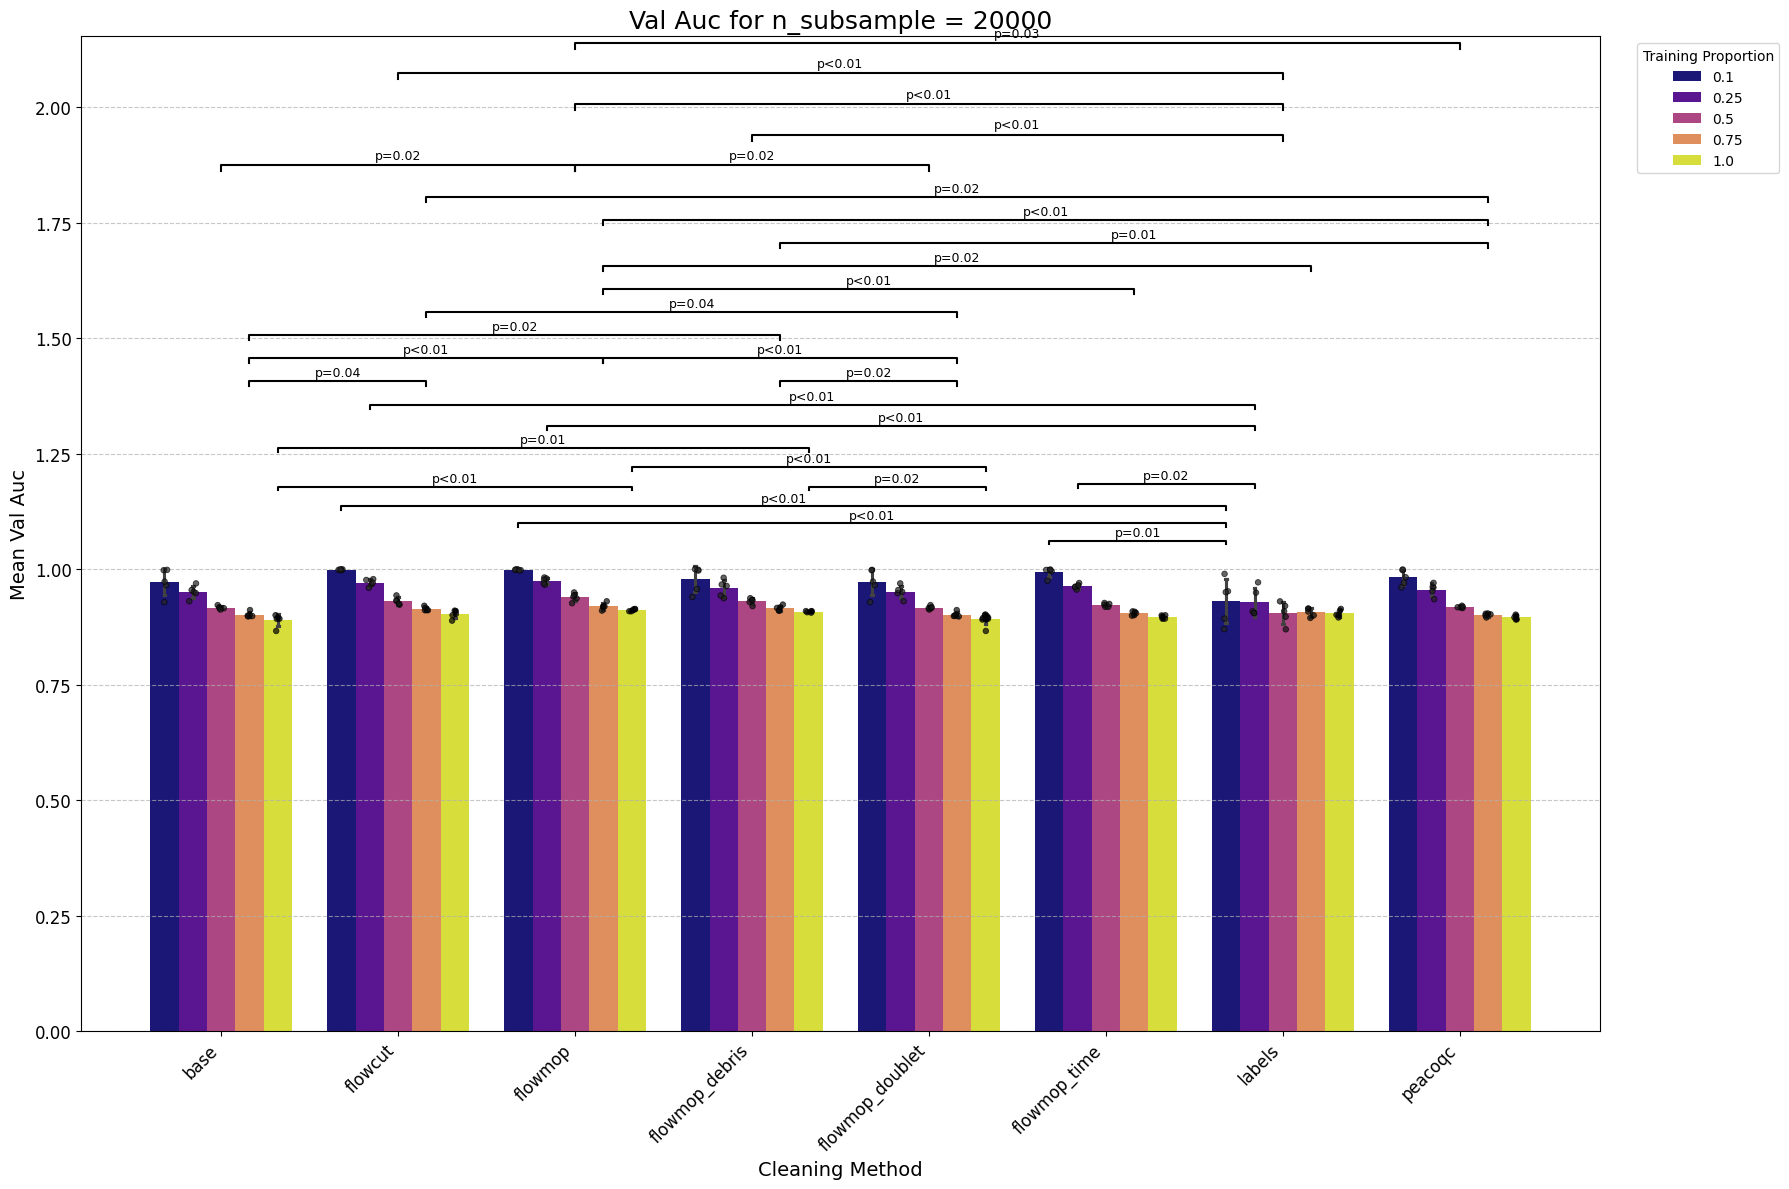

C:\Users\Tony\AppData\Local\Temp\ipykernel_18372\1992747989.py:32: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = subset.groupby('cleaning_method')[metric].apply(list)
C:\Users\Tony\AppData\Local\Temp\ipykernel_18372\2733357843.py:105: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(
C:\Users\Tony\AppData\Local\Temp\ipykernel_18372\2733357843.py:32: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  y_max_hue = data_for_hue.groupby('cleaning_method')[metric].max()
C:\Users\Tony\AppData\Lo

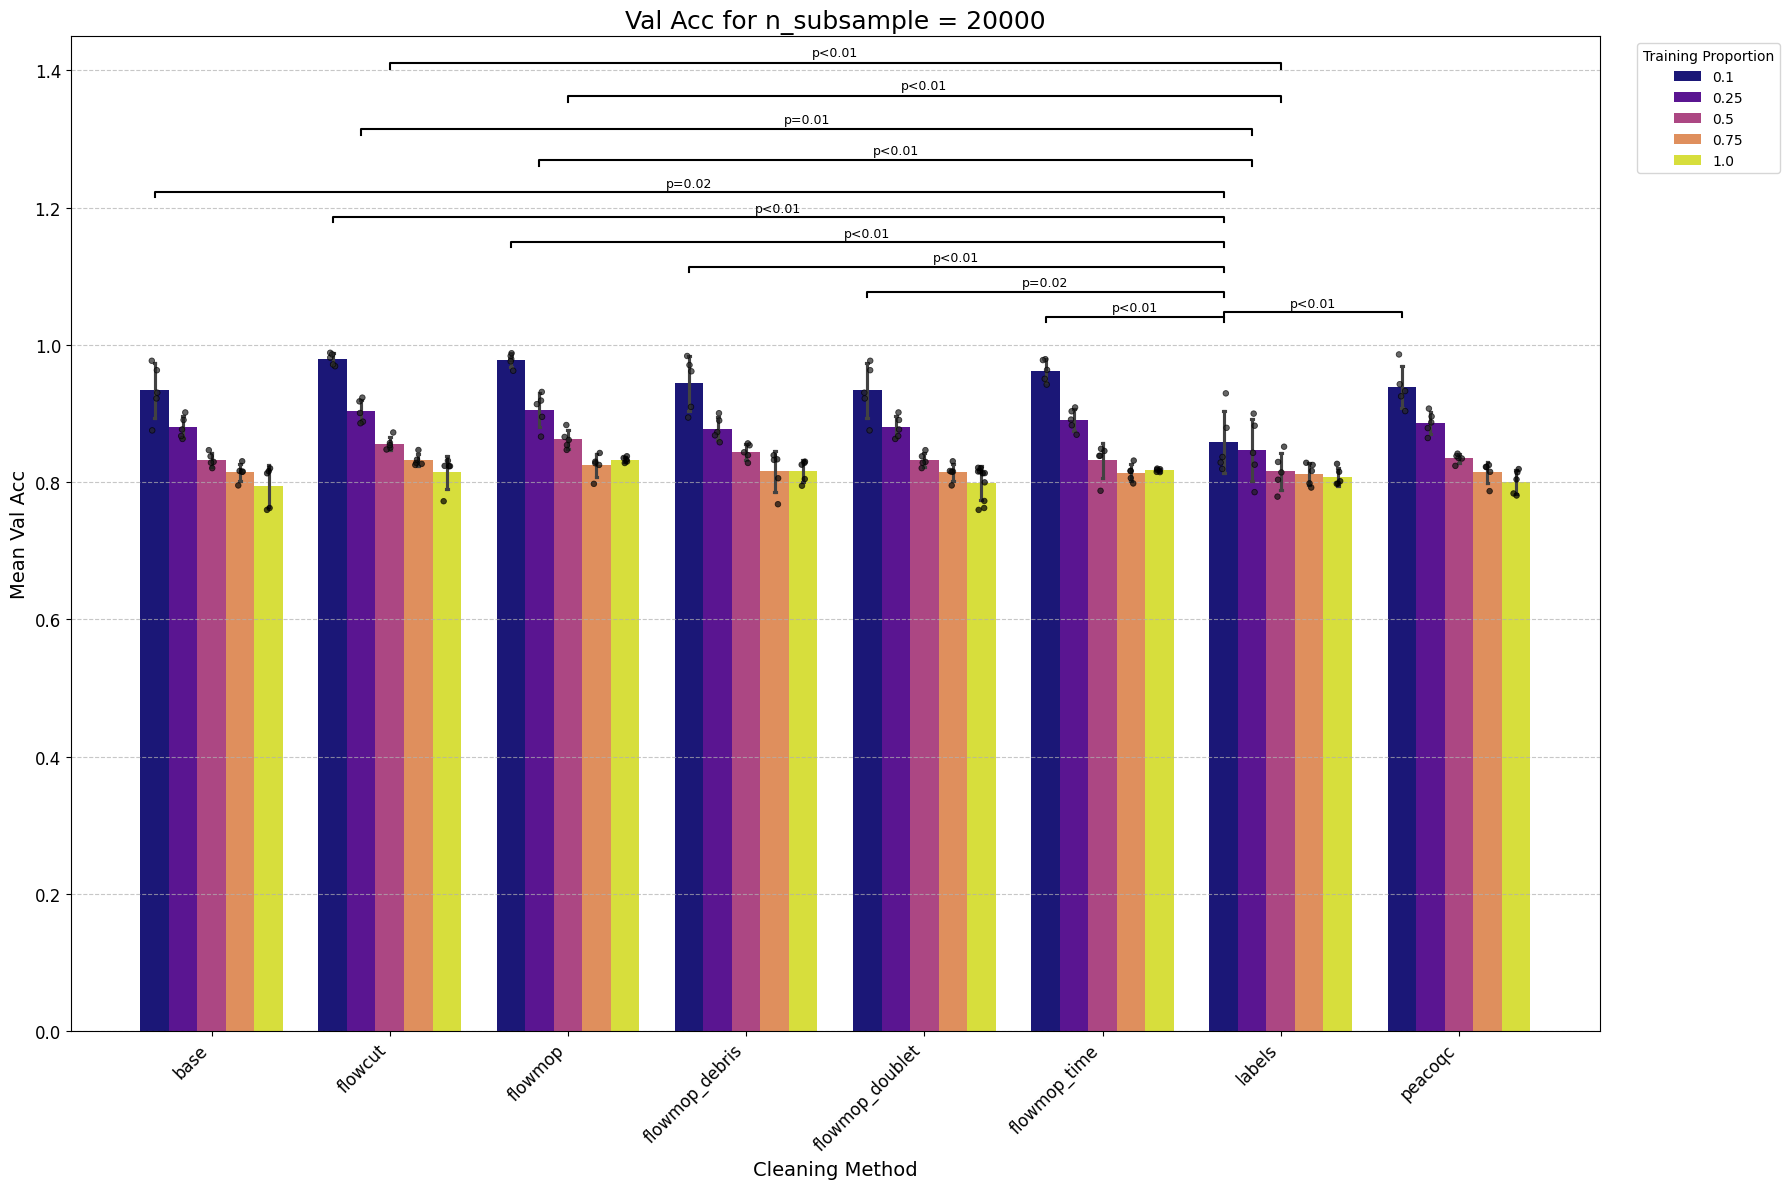

In [215]:
# --- Integrated Analysis and Plotting ---
metrics_to_test = ['testing_auc', 'testing_acc', 'val_auc', 'val_acc']
n_subsamples_to_test = [40000, 20000]

# Ensure the 'results' DataFrame is available from the initial cells
for n_sub in n_subsamples_to_test:
    df_nsub = results[results['nsubsample'] == n_sub]
    if df_nsub.empty:
        print(f"Skipping n_subsample={n_sub} as no data is available.")
        continue
    
    props_to_test = sorted(df_nsub['training_proportion'].unique())
    
    for metric in metrics_to_test:
        tukey_results_all_props = {}
        for prop in props_to_test:
            tukey_res = perform_anova_and_tukey(results, metric, n_sub, prop)
            if tukey_res is not None:
                tukey_results_all_props[prop] = tukey_res
        
        plot_metric_with_stats(results, metric, n_sub, tukey_results_all_props)

In [ ]:
def create_filtration_confusion_matrix(df, threshold_similarity=0.1):
    """
    Creates a confusion matrix-style categorization for filtration results.
    
    Categories:
    - Correctly Removed: Target and sample are similar (within threshold)
    - Incorrectly Removed: Target > Sample (over-filtered)
    - Correctly Kept: Target and sample are similar (within threshold) 
    - Incorrectly Kept: Sample > Target (under-filtered)
    
    Args:
        df: DataFrame with sample_k_count, target_k_count, diff_k_count columns
        threshold_similarity: Proportion threshold for considering counts "similar"
    
    Returns:
        DataFrame with confusion matrix categories for each k
    """
    result_df = df.copy()
    
    for k in [1, 2, 3]:
        sample_col = f'sample_{k}_count'
        target_col = f'target_{k}_count'
        diff_col = f'diff_{k}_count'
        
        if all(col in df.columns for col in [sample_col, target_col, diff_col]):
            # Calculate relative difference as proportion of target
            # Handle division by zero by using sample when target is 0
            relative_diff = df[diff_col] / df[target_col].where(df[target_col] != 0, df[sample_col].where(df[sample_col] != 0, 1))
            
            # Categorize based on the difference
            conditions = [
                (abs(relative_diff) <= threshold_similarity),  # Similar counts
                (relative_diff < -threshold_similarity),       # Sample < Target (over-filtered)
                (relative_diff > threshold_similarity)         # Sample > Target (under-filtered)
            ]
            
            choices = [
                'Correctly_Processed',  # Similar to target
                'Incorrectly_Removed',  # Over-filtered
                'Incorrectly_Kept'      # Under-filtered
            ]
            
            result_df[f'category_{k}'] = pd.cut(
                relative_diff,
                bins=[-float('inf'), -threshold_similarity, threshold_similarity, float('inf')],
                labels=['Incorrectly_Removed', 'Correctly_Processed', 'Incorrectly_Kept'],
                include_lowest=True
            )
            
            # Add quantitative measures
            result_df[f'over_filtered_degree_{k}'] = (-relative_diff).where(relative_diff < -threshold_similarity, 0)
            result_df[f'under_filtered_degree_{k}'] = relative_diff.where(relative_diff > threshold_similarity, 0)
            result_df[f'similarity_score_{k}'] = 1 - abs(relative_diff).clip(0, 1)
    
    return result_df

def summarize_confusion_matrix(df_with_categories, groupby_cols=['clean_method']):
    """
    Summarizes the confusion matrix categories by specified grouping columns.
    
    Args:
        df_with_categories: DataFrame with category columns
        groupby_cols: List of columns to group by
    
    Returns:
        Dictionary with summary statistics for each k
    """
    summaries = {}
    
    for k in [1, 2, 3]:
        category_col = f'category_{k}'
        if category_col in df_with_categories.columns:
            # Count categories by group
            category_counts = df_with_categories.groupby(groupby_cols)[category_col].value_counts().unstack(fill_value=0)
            
            # Calculate percentages
            category_percentages = category_counts.div(category_counts.sum(axis=1), axis=0) * 100
            
            # Calculate mean degrees of over/under filtering
            over_filtered_means = df_with_categories.groupby(groupby_cols)[f'over_filtered_degree_{k}'].mean()
            under_filtered_means = df_with_categories.groupby(groupby_cols)[f'under_filtered_degree_{k}'].mean()
            similarity_means = df_with_categories.groupby(groupby_cols)[f'similarity_score_{k}'].mean()
            
            summaries[f'k_{k}'] = {
                'counts': category_counts,
                'percentages': category_percentages,
                'over_filtered_degree': over_filtered_means,
                'under_filtered_degree': under_filtered_means,
                'similarity_score': similarity_means
            }
    
    return summaries

# Example usage - you'll need to load your actual data
# Assuming you have a DataFrame called 'filtration_data' with the columns you described:

# Sample data structure for demonstration
sample_data = {
    'sample_name': ['A', 'B', 'C', 'D', 'E'],
    'clean_method': ['flowmop', 'flowcut', 'peacoqc', 'flowmop', 'base'],
    'sample_1_count': [850, 920, 780, 890, 950],
    'target_1_count': [900, 900, 900, 900, 900],
    'diff_1_count': [-50, 20, -120, -10, 50],
    'sample_2_count': [450, 480, 420, 460, 500],
    'target_2_count': [500, 500, 500, 500, 500],
    'diff_2_count': [-50, -20, -80, -40, 0],
    'sample_3_count': [120, 140, 100, 130, 160],
    'target_3_count': [150, 150, 150, 150, 150],
    'diff_3_count': [-30, -10, -50, -20, 10]
}

demo_df = pd.DataFrame(sample_data)
print("Demo data structure:")
print(demo_df.head())

# Apply confusion matrix categorization
categorized_df = create_filtration_confusion_matrix(demo_df, threshold_similarity=0.1)
print("\nWith confusion matrix categories:")
print(categorized_df[['sample_name', 'clean_method', 'category_1', 'category_2', 'category_3']].head())

# Summarize by cleaning method
summary = summarize_confusion_matrix(categorized_df, ['clean_method'])
print("\nSummary for k=1:")
print("Counts:")
print(summary['k_1']['counts'])
print("\nPercentages:")
print(summary['k_1']['percentages'])